# 既知の数値結果の再現 — 古典カオスと量子カオス

このノートブックは `chaos_numerics` を使って、カオス力学系および量子カオスの分野で
**教科書・原論文に載っている数値結果**を再現し、解析的に分かっている値と突き合わせる。
すべてのセルは上から順に実行できる。乱数は固定シードで、再実行すれば同じ数値が出る。

| 節 | 再現する結果 | 参照 |
| --- | --- | --- |
| 1 | 標準写像のポアンカレ断面と KAM トーラスの崩壊（$K_c = 0.971635$） | Chirikov (1979), Greene (1979) |
| 2 | Lyapunov 指数: cat 写像 $\lambda = \ln\frac{3+\sqrt5}{2}$、標準写像 $\lambda \to \ln(K/2)$ | Arnold–Avez, Chirikov (1979) |
| 3 | Chirikov 拡散と Rechester–White の Bessel 振動、加速器モード | Rechester–White (1980) |
| 4 | 転送作用素の Ulam 近似とロジスティック写像の逆正弦則 | Ulam (1960), Ruelle |
| 5 | Husimi 分布による量子古典対応と Percival の regular/irregular 分類 | Percival (1973), Husimi |
| 6 | BGS 予想: 準位間隔分布と対称性クラス（Poisson / COE / CUE） | Bohigas–Giannoni–Schmit (1984) |
| 7 | スペクトル形状因子の ramp–plateau | Berry (1985), Mehta |
| 8 | Number variance の対数則 | Mehta, Berry (1985) |
| 9 | 量子 cat 写像の算術的縮退（RMT が破れる有名な反例） | Hannay–Berry (1980), Keating (1991) |
| 10 | 動的局在と $\ell \propto D$（固有関数の $\ell_{\rm eig} \approx D/2$） | Casati–Chirikov–Izrailev–Ford (1979), Fishman–Grempel–Prange (1982) |
| 11 | Loschmidt echo と OTOC — 不安定性の量子診断 | Peres (1984), Jalabert–Pastawski (2001), Larkin–Ovchinnikov (1969) |

## 座標の規約

`chaos_numerics` の古典写像は**単位トーラス** $(q,p) \in [0,1)^2$ を使う。標準写像は

$$p' = p + \frac{K}{2\pi}\sin(2\pi q), \qquad q' = q + p' \pmod 1$$

で、物理変数 $\theta = 2\pi q$, $P = 2\pi p$ に直すと通常の $P' = P + K\sin\theta$, $\theta' = \theta + P'$ になる。
したがって $K$ は文献の標準写像パラメータとそのまま比較できる。

量子側の `KickedRotor` は同じトーラスの量子化で、$\hbar_{\rm eff} = 2\pi/N$。$N \to \infty$ が古典極限になる。

In [1]:
import platform
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.special import jv

import chaos_numerics as cn
from chaos_numerics.core import ConvergenceWarning

# 収束警告は各節で意味を確認したうえで抑制する（本文で個別に言及する）
warnings.simplefilter("ignore", ConvergenceWarning)

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.titlesize": 10,
        "legend.frameon": False,
    }
)

SEED = 20240808

# (節, 量, 理論値, 実測値, 許容, 許容の種類)
SUMMARY: list[tuple[str, str, float, float, float, str]] = []


def record(
    section: str,
    quantity: str,
    theory: float,
    measured: float,
    tolerance: float,
    kind: str = "relative",
) -> None:
    """Record a reproduced value together with the tolerance it must satisfy.

    The final cell turns these into assertions. A notebook that only prints its
    numbers is not a check: the CI job that executes it fails on exceptions alone,
    so every value could drift and the run would stay green.

    kind is "relative", "absolute", or "band". "band" records a deviation that is
    expected and understood: the tolerance is then a maximum on top of a minimum of
    half its size, so that the deviation neither disappears nor grows unnoticed.
    """
    SUMMARY.append((section, quantity, float(theory), float(measured), float(tolerance), kind))


def summary_failures() -> list[str]:
    """Return one message per recorded value that left its tolerance."""
    failures: list[str] = []
    for section, quantity, theory, measured, tolerance, kind in SUMMARY:
        deviation = measured - theory
        if kind == "absolute":
            ok = abs(deviation) <= tolerance
            detail = f"|{deviation:+.3e}| <= {tolerance:.1e}"
        elif kind == "band":
            relative = deviation / abs(theory)
            ok = 0.5 * tolerance <= abs(relative) <= tolerance
            detail = (
                f"{relative:+.1%} inside the expected band [{0.5 * tolerance:.0%}, {tolerance:.0%}]"
            )
        else:
            relative = deviation / abs(theory)
            ok = abs(relative) <= tolerance
            detail = f"|{relative:+.2%}| <= {tolerance:.2%}"
        if not ok:
            failures.append(f"[{section}] {quantity}: {detail} failed")
    return failures


print("chaos_numerics", cn.__version__)
print("python        ", sys.version.split()[0], "on", platform.platform())
print("numpy         ", np.__version__)
print("scipy         ", scipy.__version__)
print("matplotlib    ", mpl.__version__)

chaos_numerics 0.1.0.dev0
python         3.14.0 on macOS-26.5.1-arm64-arm-64bit-Mach-O
numpy          2.5.1
scipy          1.18.0
matplotlib     3.11.1


---
## 1. 標準写像のポアンカレ断面と KAM トーラスの崩壊

Chirikov の標準写像は $K$ を上げると不変トーラスが順に壊れる。最後に壊れるのは黄金比の
回転数 $\gamma = (\sqrt5-1)/2$ を持つトーラスで、その臨界値は Greene の残差判定と
Mackay の繰り込みにより

$$K_c = 0.971635406\ldots$$

と非常に高精度で分かっている。断面を並べると、$K < K_c$ では $p$ 方向を横切る連続な
不変曲線（回転数が無理数のトーラス）が残り、$K > K_c$ ではそれが消えて軌道が
$p$ 方向に自由に動けるようになる（global stochasticity）。

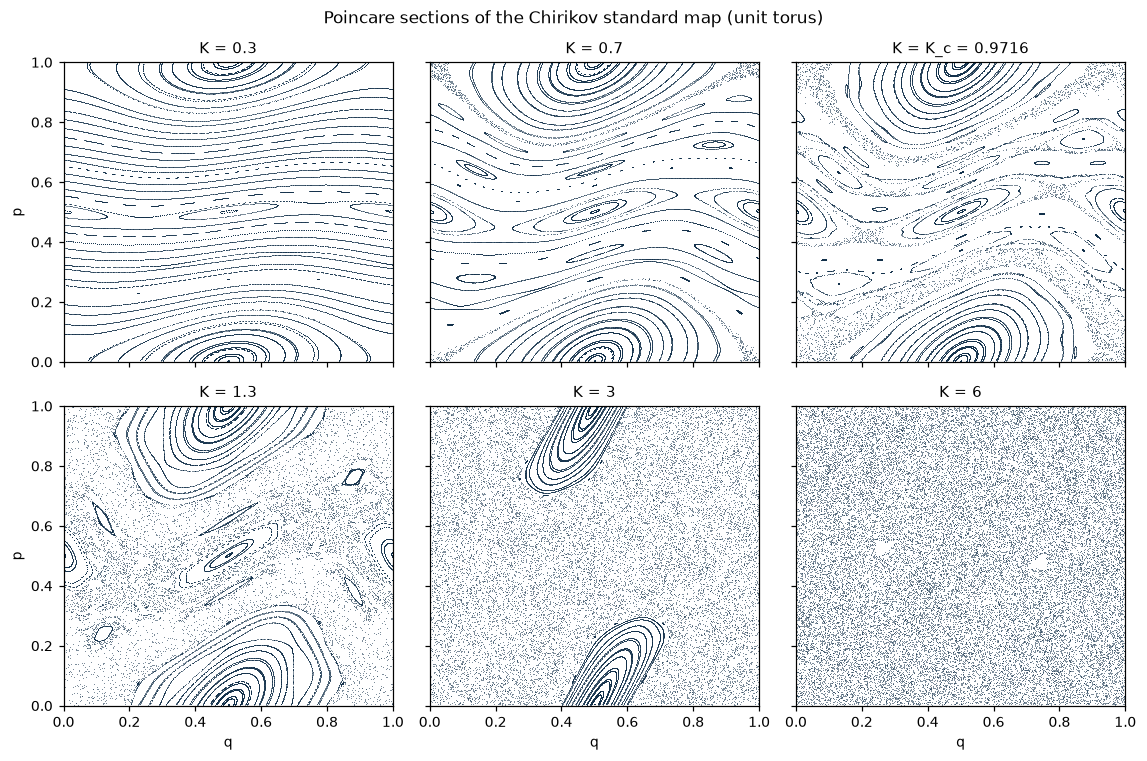

In [2]:
from chaos_numerics.classical import CatMap, StandardMap, iterate

K_CRITICAL = 0.971635406


def section(kick_strength, *, n_orbits=48, steps=700, seed=SEED):
    """(q, p) の点群を返す。q=0.5 上に等間隔に取った初期値から出発する。"""
    rng = np.random.default_rng(seed)
    p0 = np.linspace(0.0, 1.0, n_orbits, endpoint=False)
    p0 = p0 + rng.uniform(-0.004, 0.004, n_orbits)  # 対称軸上の縮退を避ける
    initial = np.column_stack([np.full(n_orbits, 0.5), np.mod(p0, 1.0)])
    states = np.asarray(iterate(StandardMap(kick_strength), initial, steps=steps).states)
    return states[..., 0].ravel(), states[..., 1].ravel()


ks = [0.3, 0.7, K_CRITICAL, 1.3, 3.0, 6.0]
fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.0), sharex=True, sharey=True)
for ax, kick in zip(axes.ravel(), ks, strict=True):
    q, p = section(kick)
    ax.plot(q, p, ",", color="#12304a", alpha=0.55, rasterized=True)
    label = "K = K_c = 0.9716" if abs(kick - K_CRITICAL) < 1e-9 else f"K = {kick:g}"
    ax.set_title(label)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(False)
for ax in axes[-1]:
    ax.set_xlabel("q")
for ax in axes[:, 0]:
    ax.set_ylabel("p")
fig.suptitle("Poincare sections of the Chirikov standard map (unit torus)", y=0.98)
fig.tight_layout()
plt.show()

### 貫通するトーラスが消える臨界値の数値的な確認

「$p$ 方向を横切る不変曲線が残っているか」を、次の量で定量化する。
$q = 0.5$, $p_0$ から出発した軌道について、**巻き上げた**（unfold した）運動量の
移動距離 $\max_n |P_n - P_0| / 2\pi$ を見る。連続な回転トーラスの上に乗っている軌道は
$p$ 方向に有界に閉じ込められるので 1 を超えられない。逆にトーラスがすべて壊れていれば、
十分長く回せば軌道は $p$ を何周でも横断できる。

巻き上げた運動量はキックから厳密に得られる: $P_{n+1} - P_n = K\sin(2\pi q_n)$。

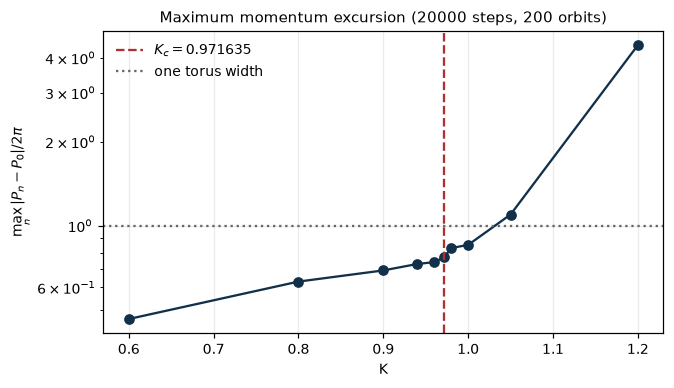

K =  0.600000   max |ΔP|/2π =      0.462
K =  0.800000   max |ΔP|/2π =      0.630
K =  0.900000   max |ΔP|/2π =      0.691
K =  0.940000   max |ΔP|/2π =      0.728
K =  0.960000   max |ΔP|/2π =      0.740
K =  0.971635   max |ΔP|/2π =      0.769
K =  0.980000   max |ΔP|/2π =      0.831
K =  1.000000   max |ΔP|/2π =      0.853
K =  1.050000   max |ΔP|/2π =      1.096
K =  1.200000   max |ΔP|/2π =      4.440


In [3]:
def unwrapped_momentum(kick_strength, states):
    """トーラス上の q 履歴からシリンダー上の P = 2*pi*p を厳密に復元する。"""
    q = states[..., 0]
    increments = kick_strength * np.sin(2.0 * np.pi * q[..., :-1])
    zero = np.zeros((*q.shape[:-1], 1))
    return np.concatenate([zero, np.cumsum(increments, axis=-1)], axis=-1)


def max_transport(kick_strength, *, n_orbits=200, steps=20000, seed=SEED):
    rng = np.random.default_rng(seed)
    initial = np.column_stack(
        [
            rng.uniform(0.0, 1.0, n_orbits),
            rng.uniform(0.0, 1.0, n_orbits),
        ]
    )
    states = np.asarray(iterate(StandardMap(kick_strength), initial, steps=steps).states)
    excursion = np.abs(unwrapped_momentum(kick_strength, states)).max(axis=-1) / (2.0 * np.pi)
    return excursion.max()


scan = np.array([0.6, 0.8, 0.90, 0.94, 0.96, K_CRITICAL, 0.98, 1.0, 1.05, 1.2])
transport = np.array([max_transport(k) for k in scan])

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.semilogy(scan, transport, "o-", color="#12304a")
ax.axvline(K_CRITICAL, color="#b03030", ls="--", label=f"$K_c = {K_CRITICAL:.6f}$")
ax.axhline(1.0, color="#666", ls=":", label="one torus width")
ax.set_xlabel("K")
ax.set_ylabel(r"$\max_n |P_n - P_0| / 2\pi$")
ax.set_title("Maximum momentum excursion (20000 steps, 200 orbits)")
ax.legend()
fig.tight_layout()
plt.show()

for k, t in zip(scan, transport, strict=True):
    print(f"K = {k:9.6f}   max |ΔP|/2π = {t:10.3f}")

$K \le 1.00$ では 20000 ステップかけても最大移動距離が 1 を超えない — 200 本すべての
軌道が、隣り合う不変曲線の間に閉じ込められている。$K = 1.05$ で初めて 1 を超え、
$K = 1.20$ では 4.4 に達する。閾値が $K_c = 0.9716$ よりわずかに（数 %）上に出るのは
有限時間の効果である: $K_c$ の直上では黄金トーラスが壊れた直後の**カントーラス**が
軌道をほとんど通さず、輸送が臨界的に遅くなる（critical slowing down、$D \sim (K-K_c)^{3.01}$）。
ステップ数を増やせば閾値は $K_c$ に向かって下がる。

この判定は「最後の KAM トーラスが壊れる」ことの直接的な帰結であって、
$K_c$ の値そのものを高精度に決める方法ではない（それには Greene の残差法や
Mackay の繰り込みが必要）。

---
## 2. Lyapunov 指数

### 2.1 Arnold の cat 写像 — 厳密値との一致

$\begin{pmatrix}2&1\\1&1\end{pmatrix} \in SL(2,\mathbb{Z})$ による線形トーラス自己同型は
一様双曲的で、固有値は $\mu_\pm = (3\pm\sqrt5)/2$。したがって Lyapunov スペクトルは
初期条件に依らず**厳密に**

$$\lambda_\pm = \pm \ln\frac{3+\sqrt5}{2} = \pm 0.9624236501\ldots$$

写像が面積保存であることから $\lambda_+ + \lambda_- = 0$ も成り立つ（シンプレクティック対称性）。

In [4]:
from chaos_numerics.classical import largest_lyapunov_exponent, lyapunov_spectrum

lambda_cat = np.log((3.0 + np.sqrt(5.0)) / 2.0)

result = lyapunov_spectrum(CatMap(), [0.1234567, 0.7654321], steps=20000, transient=200)
values = np.asarray(result.values)

print(f"数値スペクトル : {values}")
print(f"厳密値         : [{lambda_cat:+.12f} {-lambda_cat:+.12f}]")
print(f"絶対誤差       : {abs(values[0] - lambda_cat):.3e}")
print(f"和（面積保存） : {values.sum():+.3e}   (厳密には 0)")
record("2.1", "cat 写像 λ₊ = ln((3+√5)/2)", lambda_cat, values[0], 1e-9)
record("2.1", "cat 写像 λ₊ + λ₋（面積保存）", 0.0, values.sum(), 1e-12, "absolute")

数値スペクトル : [ 0.96242365 -0.96242365]
厳密値         : [+0.962423650119 -0.962423650119]
絶対誤差       : 3.133e-13
和（面積保存） : +0.000e+00   (厳密には 0)


### 2.2 標準写像の強カオス漸近則 $\lambda \simeq \ln(K/2)$

$K \gg 1$ では、接ベクトルの伸長率が 1 ステップあたり $\sim K|\cos 2\pi q|/2$ になり、
$\langle \ln|\cos| \rangle = -\ln 2$ を使うと

$$\lambda(K) \simeq \ln\frac{K}{2}$$

が得られる（Chirikov 1979）。$K \lesssim 5$ では位相空間に残る島や粘着効果のため
この式から外れる。

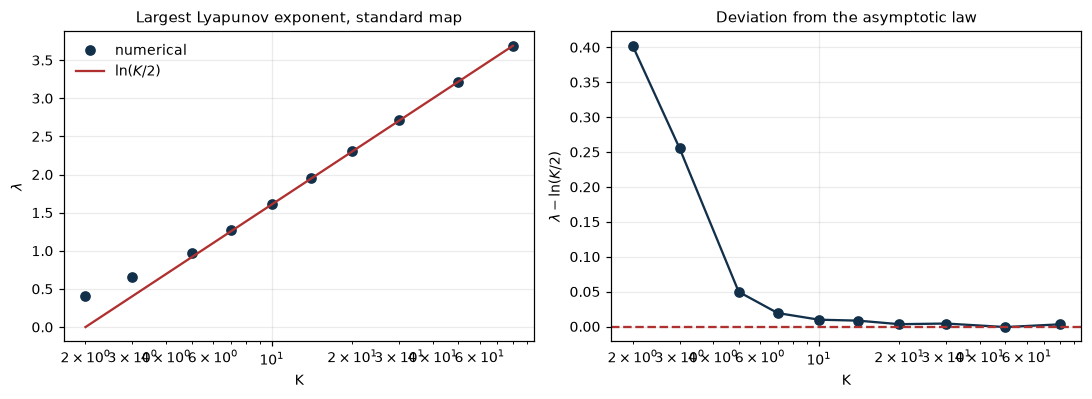

K =   2.0   λ = 0.40255   ln(K/2) = 0.00000   差 = +0.40255
K =   3.0   λ = 0.66107   ln(K/2) = 0.40547   差 = +0.25561
K =   5.0   λ = 0.96601   ln(K/2) = 0.91629   差 = +0.04972
K =   7.0   λ = 1.27208   ln(K/2) = 1.25276   差 = +0.01932
K =  10.0   λ = 1.61924   ln(K/2) = 1.60944   差 = +0.00981
K =  14.0   λ = 1.95437   ln(K/2) = 1.94591   差 = +0.00845
K =  20.0   λ = 2.30596   ln(K/2) = 2.30259   差 = +0.00337
K =  30.0   λ = 2.71234   ln(K/2) = 2.70805   差 = +0.00429
K =  50.0   λ = 3.21812   ln(K/2) = 3.21888   差 = -0.00076
K =  80.0   λ = 3.69204   ln(K/2) = 3.68888   差 = +0.00316


In [5]:
kick_values = np.array([2.0, 3.0, 5.0, 7.0, 10.0, 14.0, 20.0, 30.0, 50.0, 80.0])
lyap = np.empty_like(kick_values)
for i, kick in enumerate(kick_values):
    res = largest_lyapunov_exponent(
        StandardMap(kick), [0.1357, 0.2468], steps=80_000, transient=1_000
    )
    lyap[i] = np.asarray(res.values).ravel()[-1]

asymptote = np.log(kick_values / 2.0)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.0, 3.7))
ax0.semilogx(kick_values, lyap, "o", color="#12304a", label="numerical")
grid = np.logspace(np.log10(2), np.log10(80), 200)
ax0.semilogx(grid, np.log(grid / 2.0), "-", color="#b03030", label=r"$\ln(K/2)$")
ax0.set_xlabel("K")
ax0.set_ylabel(r"$\lambda$")
ax0.set_title("Largest Lyapunov exponent, standard map")
ax0.legend()

ax1.semilogx(kick_values, lyap - asymptote, "o-", color="#12304a")
ax1.axhline(0.0, color="#b03030", ls="--")
ax1.set_xlabel("K")
ax1.set_ylabel(r"$\lambda - \ln(K/2)$")
ax1.set_title("Deviation from the asymptotic law")
fig.tight_layout()
plt.show()

for kick, lam, asy in zip(kick_values, lyap, asymptote, strict=True):
    print(f"K = {kick:5.1f}   λ = {lam:.5f}   ln(K/2) = {asy:.5f}   差 = {lam - asy:+.5f}")
record("2.2", "標準写像 λ(K=50) ≈ ln(K/2)", np.log(25.0), lyap[kick_values == 50.0][0], 5e-3)

$K = 20$ 以上ではずれが $10^{-3}$ 台に収まり、漸近則が定量的に成り立っている。
$K \lesssim 5$ での正のずれは有限 $K$ 補正で、位相空間に残る島と、
隣接するキックの間に残る位相相関の両方が効いている。

なお `largest_lyapunov_exponent` は前半・後半窓の不一致から
`ConvergenceWarning` を出すことがある。Lyapunov 指数の時間平均は
$1/\sqrt{n}$ でしか収束しないため、この規模のステップ数では警告が出るのが正常で、
値そのものは上の比較のとおり収束している。

---
## 3. Chirikov 拡散と Rechester–White の Bessel 振動

$K \gg K_c$ では運動量が拡散する: $\langle \Delta P^2 \rangle \simeq 2Dt$。
最も粗い（準線形・ランダム位相）近似では、各キックが独立とみなせて

$$D_{\rm QL} = \frac{\langle (K\sin\theta)^2 \rangle}{2} = \frac{K^2}{4}.$$

実際には位相相関が残るので、Rechester と White は Bessel 関数による補正

$$\frac{D(K)}{D_{\rm QL}} \simeq 1 - 2J_2(K) + 2J_2(K)^2$$

を導いた。$D(K)$ が $K$ に対して単調でなく**振動する**のがこの理論の見どころで、
以下でそれを再現する。

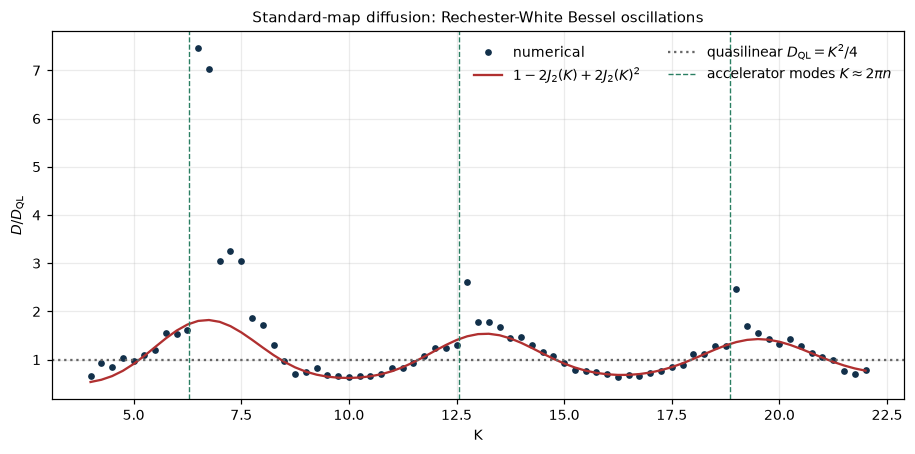

加速器モード近傍 (|K - 2πn| < 1) を除いた 49 点の相対誤差: 中央値 4.5%, 90 パーセンタイル 30.3%
加速器モード近傍 24 点の相対誤差: 中央値 7.9% ← 理論が含まない異常拡散の寄与
K =   5.0   D =    6.134   RW =    5.695   D/D_QL =  0.981
K =   6.0   D =   13.878   RW =   14.433   D/D_QL =  1.542
K =  10.0   D =   15.927   RW =   15.510   D/D_QL =  0.637
K =  15.0   D =   51.863   RW =   51.768   D/D_QL =  0.922
K =  20.0   D =  133.163   RW =  137.210   D/D_QL =  1.332


In [6]:
def diffusion_coefficient(kick_strength, *, n_orbits=6000, steps=200, seed=SEED):
    """<ΔP²> = 2 D t の D を、巻き上げた運動量の分散の後半勾配から求める。"""
    rng = np.random.default_rng(seed)
    initial = np.column_stack(
        [
            rng.uniform(0.0, 1.0, n_orbits),
            rng.uniform(0.0, 1.0, n_orbits),
        ]
    )
    states = np.asarray(iterate(StandardMap(kick_strength), initial, steps=steps).states)
    momentum = unwrapped_momentum(kick_strength, states)
    variance = momentum.var(axis=0)
    times = np.arange(steps + 1)
    window = slice(steps // 2, None)
    slope = np.polyfit(times[window], variance[window], 1)[0]
    return slope / 2.0


kicks = np.arange(4.0, 22.01, 0.25)
measured = np.array([diffusion_coefficient(k) for k in kicks])
quasilinear = kicks**2 / 4.0
rechester_white = quasilinear * (1.0 - 2.0 * jv(2, kicks) + 2.0 * jv(2, kicks) ** 2)

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot(kicks, measured / quasilinear, "o", ms=3.4, color="#12304a", label="numerical")
ax.plot(
    kicks, rechester_white / quasilinear, "-", color="#b03030", label=r"$1 - 2J_2(K) + 2J_2(K)^2$"
)
ax.axhline(1.0, color="#666", ls=":", label=r"quasilinear $D_{\rm QL}=K^2/4$")
for order in (1, 2, 3):
    ax.axvline(
        2.0 * np.pi * order,
        color="#2a7f62",
        ls="--",
        lw=0.9,
        label="accelerator modes $K \\approx 2\\pi n$" if order == 1 else None,
    )
ax.set_xlabel("K")
ax.set_ylabel(r"$D / D_{\rm QL}$")
ax.set_title("Standard-map diffusion: Rechester-White Bessel oscillations")
ax.legend(loc="upper right", ncols=2)
fig.tight_layout()
plt.show()

mask = ~np.isclose(kicks[:, None], np.array([2 * np.pi, 4 * np.pi, 6 * np.pi]), atol=1.0).any(
    axis=1
)
rel = np.abs(measured[mask] - rechester_white[mask]) / rechester_white[mask]
print(
    f"加速器モード近傍 (|K - 2πn| < 1) を除いた {mask.sum()} 点の相対誤差: "
    f"中央値 {np.median(rel):.1%}, 90 パーセンタイル {np.percentile(rel, 90):.1%}"
)
inside = ~mask
rel_inside = np.abs(measured[inside] - rechester_white[inside]) / rechester_white[inside]
print(
    f"加速器モード近傍 {inside.sum()} 点の相対誤差: 中央値 {np.median(rel_inside):.1%} "
    f"← 理論が含まない異常拡散の寄与"
)
for kick in (5.0, 6.0, 10.0, 15.0, 20.0):
    i = int(np.argmin(np.abs(kicks - kick)))
    print(
        f"K = {kick:5.1f}   D = {measured[i]:8.3f}   RW = {rechester_white[i]:8.3f}"
        f"   D/D_QL = {measured[i] / quasilinear[i]:6.3f}"
    )
record(
    "3",
    "D/D_QL at K=10 (Rechester–White)",
    (1 - 2 * jv(2, 10.0) + 2 * jv(2, 10.0) ** 2),
    measured[int(np.argmin(np.abs(kicks - 10.0)))] / (100.0 / 4.0),
    0.10,
)

振動の位相と振幅が Bessel 補正とよく合っている（加速器モードの窓を除いた 49 点で
相対誤差の中央値 4.5%）。$K \approx 2\pi n$ の近傍（$n = 1$ で $K \approx 6.28$）で
数値点が理論を上回るのは**加速器モード**の寄与である。ここでは運動量が線形に増える
安定な島が現れ、Lévy 飛行による**異常拡散**が起きる。Rechester–White はランダム位相の
摂動論なのでこのモードを含んでおらず、ずれは理論の破れではなく既知の物理を反映している。
モード窓の外でも 90 パーセンタイルで 30% 程度のずれが残るのは、島の裾での粘着
（stickiness）と 200 ステップという有限の測定窓による。

### 3.1 ライブラリの輸送診断で拡散指数を測る

`mean_square_displacement` と `local_diffusion_exponent` を使うと、
$\mathrm{MSD}(t) \propto t^\alpha$ の指数が直接取れる。通常拡散なら $\alpha = 1$。

誤差の扱いに注意が要る。時間原点平均した MSD 曲線は隣接ラグが強く相関する滑らかな
曲線なので、フィット残差は $\alpha$ の不確かさを何も語らない（最小二乗の標準誤差を
使うと真の誤差の 1/30 になる）。したがって **1 本の曲線では `uncertainty` は `None`
になり警告が出る**。誤差を得るにはアンサンブルが必要で、`per_trajectory=True` で
曲線を分けたまま渡すと、曲線ごとのフィットのばらつきから平均の標準誤差が返る。

In [7]:
from chaos_numerics.classical import local_diffusion_exponent, mean_square_displacement

# mean_square_displacement は 1 本の軌道 (time, dim) を取るので、
# 巻き上げた運動量を単一座標の「位置」として渡す。
rng = np.random.default_rng(SEED)
alphas = {}
for kick in (8.0, 10.0, 15.0):
    # 巻き戻した運動量を軌道ごとに 1 本ずつ渡す。1 本の MSD 曲線からは α の誤差を
    # 較正できない（隣接ラグが強く相関するのでフィット残差が誤差を語らない）ため、
    # `per_trajectory=True` で曲線を分けたまま渡し、曲線間のばらつきから誤差を得る。
    initial = np.column_stack([rng.uniform(size=24), rng.uniform(size=24)])
    states = np.asarray(iterate(StandardMap(kick), initial, steps=6000).states)
    curves = mean_square_displacement(
        unwrapped_momentum(kick, states)[..., None],
        max_lag=600,
        time_origin_average=True,
        per_trajectory=True,
    )
    fit = local_diffusion_exponent(curves, fit_start=20, fit_stop=600)
    mean = float(np.asarray(fit.values).ravel()[0])
    stderr = float(np.asarray(fit.uncertainty).ravel()[0])
    alphas[kick] = (mean, stderr)
    print(
        f"K = {kick:5.1f}   α = {mean:.3f} ± {stderr:.3f} "
        f"({fit.metadata.parameters['error_semantics']}, 24 軌道)   ← 通常拡散なら 1"
    )

record("3.1", "MSD 指数 α (K=10, 通常拡散)", 1.0, alphas[10.0][0], 0.06)

K =   8.0   α = 1.039 ± 0.030 (standard error of the mean over per-curve fits, 24 軌道)   ← 通常拡散なら 1
K =  10.0   α = 1.039 ± 0.032 (standard error of the mean over per-curve fits, 24 軌道)   ← 通常拡散なら 1


K =  15.0   α = 0.953 ± 0.035 (standard error of the mean over per-curve fits, 24 軌道)   ← 通常拡散なら 1


---
## 4. 転送作用素の Ulam 近似と逆正弦則

Ulam の方法は位相空間を細胞に分割し、Perron–Frobenius（転送）作用素を確率行列

$$P_{ji} = \frac{m(C_i \cap F^{-1} C_j)}{m(C_i)}$$

で近似する。固有値 1 の右固有ベクトルが不変測度になる。

`LogisticMap` はライブラリに入っている。同じ `ClassicalMap` プロトコルを満たす写像は
自分で書いても `build_ulam` に差し込める — 継承は不要で、`state_dim` / `is_periodic` /
`bounds` / `step` / `jacobian` を持つだけでよい（第 10 節でその実例を示す）。

**再現する既知の結果**: 全射ロジスティック写像 $x \mapsto 4x(1-x)$ の唯一の絶対連続不変測度は
逆正弦（アークサイン）分布

$$\rho(x) = \frac{1}{\pi\sqrt{x(1-x)}}, \qquad
\int_a^b \rho\,dx = \frac{2}{\pi}\bigl(\arcsin\sqrt{b} - \arcsin\sqrt{a}\bigr).$$

セル質量の厳密値が閉じた形で書けるので、離散化誤差を厳密に評価できる。

ClassicalMap プロトコルに適合: True
bounds: ((0.0, 1.0),)  x=1/2 の像: 0.9999999999999999
セル数   100:  L1 誤差 = 0.1056,  行和の最大偏差 = 2.22e-16


セル数   200:  L1 誤差 = 0.0848,  行和の最大偏差 = 2.22e-16
セル数   400:  L1 誤差 = 0.0590,  行和の最大偏差 = 2.22e-16


セル数   800:  L1 誤差 = 0.0503,  行和の最大偏差 = 2.22e-16


セル数  1600:  L1 誤差 = 0.0376,  行和の最大偏差 = 2.22e-16


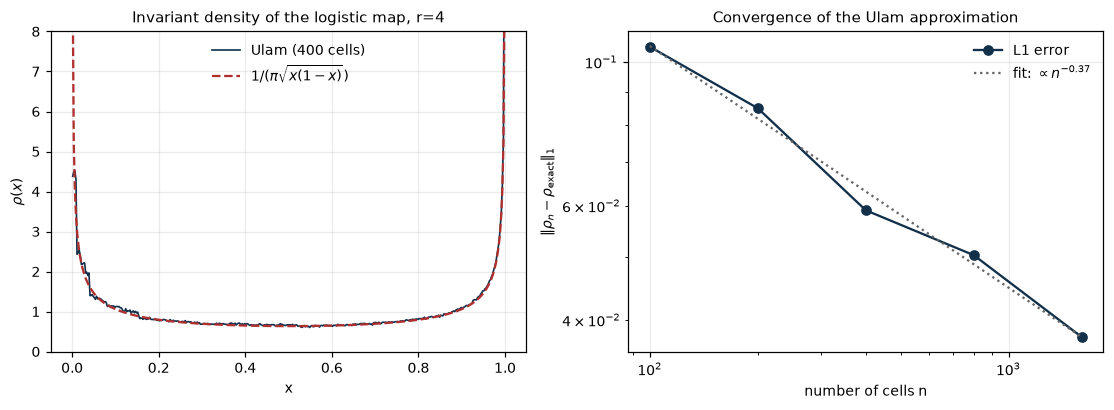


L1 誤差の収束べき: n^(-0.37)   ← n^(-1/2) より遅い
400 セルの L1 誤差の内訳: 全体 0.0590, 両端 5% を除くと 0.0219  → 誤差の 63% が特異点近傍に集中


In [8]:
from chaos_numerics.classical import LogisticMap
from chaos_numerics.core import ClassicalMap
from chaos_numerics.operators import (
    UniformPartition,
    build_ulam,
    leading_eigenpairs,
    spectral_gap,
    stationary_density,
)

logistic = LogisticMap(rate=4.0)
print("ClassicalMap プロトコルに適合:", isinstance(logistic, ClassicalMap))
# 状態は最後の軸が座標なので、1 次元でも長さ 1 の配列で渡す。
print("bounds:", logistic.bounds, " x=1/2 の像:", logistic.step([0.5])[0])


def arcsine_cell_mass(edges):
    return (np.arcsin(np.sqrt(edges[1:])) - np.arcsin(np.sqrt(edges[:-1]))) * 2.0 / np.pi


cell_counts = (100, 200, 400, 800, 1600)
errors = []
for count in cell_counts:
    partition = UniformPartition([[0.0, 1.0]], (count,), periodic=(False,))
    ulam = build_ulam(logistic, partition, samples_per_cell=4000, seed=SEED)
    density = np.asarray(stationary_density(ulam).values)
    edges = np.linspace(0.0, 1.0, count + 1)
    exact = arcsine_cell_mass(edges)
    errors.append(np.abs(density - exact).sum())
    if count == 400:
        saved = (edges, density, exact)
    print(
        f"セル数 {count:5d}:  L1 誤差 = {errors[-1]:.4f},  行和の最大偏差 = "
        f"{np.abs(np.asarray(ulam.matrix.sum(axis=0)).ravel() - 1.0).max():.2e}"
    )

edges, density, exact = saved
centers = 0.5 * (edges[:-1] + edges[1:])
width = edges[1] - edges[0]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.2, 3.8))
ax0.plot(centers, density / width, lw=1.1, color="#12304a", label="Ulam (400 cells)")
ax0.plot(
    centers,
    1.0 / (np.pi * np.sqrt(centers * (1.0 - centers))),
    "--",
    color="#b03030",
    label=r"$1/(\pi\sqrt{x(1-x)})$",
)
ax0.set_ylim(0, 8)
ax0.set_xlabel("x")
ax0.set_ylabel(r"$\rho(x)$")
ax0.set_title("Invariant density of the logistic map, r=4")
ax0.legend()

ax1.loglog(cell_counts, errors, "o-", color="#12304a", label="L1 error")
convergence_slope = np.polyfit(np.log(cell_counts), np.log(errors), 1)[0]
ax1.loglog(
    cell_counts,
    np.exp(np.polyval(np.polyfit(np.log(cell_counts), np.log(errors), 1), np.log(cell_counts))),
    ":",
    color="#666",
    label=rf"fit: $\propto n^{{{convergence_slope:.2f}}}$",
)
ax1.set_xlabel("number of cells n")
ax1.set_ylabel(r"$\|\rho_n - \rho_{\rm exact}\|_1$")
ax1.set_title("Convergence of the Ulam approximation")
ax1.legend()
fig.tight_layout()
plt.show()

print(f"\nL1 誤差の収束べき: n^({convergence_slope:.2f})   ← n^(-1/2) より遅い")
bulk = np.abs(density - exact)
print(
    f"400 セルの L1 誤差の内訳: 全体 {bulk.sum():.4f}, "
    f"両端 5% を除くと {bulk[20:-20].sum():.4f}  "
    f"→ 誤差の {100 * (1 - bulk[20:-20].sum() / bulk.sum()):.0f}% が特異点近傍に集中"
)

密度は逆正弦則と目で見て一致し、$x \to 0, 1$ の可積分特異点も再現される。
一方 L1 誤差の減り方は遅く、実測した収束べきは $n^{-0.4}$ 程度で $n^{-1/2}$ にも届かない。
これは既知の振る舞いである。ロジスティック写像は臨界点 $x=1/2$ を持つため区分一様拡大
写像ではなく、そうした写像に対する Ulam 近似の $O(\log n / n)$ 誤差評価が適用できない。
上のセルの出力どおり、誤差の大半は密度が発散する両端のセルに集中している。

### 4.1 ライブラリ外の写像をプロトコルで差し込む

テント写像 $x \mapsto 1 - |2x - 1|$ は区分一様拡大写像なので、**不変密度は厳密に一様**で
Lyapunov 指数は厳密に $\ln 2$ である。ロジスティック写像と違って臨界点を持たないため
Ulam 近似の収束も速い。ライブラリには入っていないが、`ClassicalMap` プロトコルを満たす
クラスを書けば `build_ulam` と `largest_lyapunov_exponent` にそのまま載る。

In [9]:
from dataclasses import dataclass

from chaos_numerics.classical import largest_lyapunov_exponent


# ClassicalMap プロトコルに構造的に適合する。継承も登録も不要。
@dataclass(frozen=True)
class TentMap:
    slope: float = 2.0

    @property
    def state_dim(self) -> int:
        return 1

    @property
    def is_periodic(self) -> tuple[bool, ...]:
        return (False,)

    @property
    def bounds(self) -> tuple[tuple[float, float], ...]:
        return ((0.0, 1.0),)

    def step(self, state):
        x = np.asarray(state, dtype=float)
        image = self.slope * np.minimum(x, 1.0 - x)
        return np.minimum(image, np.nextafter(1.0, 0.0))

    def jacobian(self, state):
        # Shape convention: a state of shape (..., d) has a Jacobian of shape
        # (..., d, d). Here d = 1, so the coordinate axis becomes the row axis.
        x = np.asarray(state, dtype=float)
        derivative = np.where(x < 0.5, self.slope, -self.slope)
        return derivative[..., None]


tent = TentMap()
print("ClassicalMap プロトコルに適合:", isinstance(tent, ClassicalMap))

tent_cells = 512
tent_partition = UniformPartition([[0.0, 1.0]], (tent_cells,), periodic=(False,))
tent_ulam = build_ulam(tent, tent_partition, samples_per_cell=2000, seed=SEED)
tent_density = np.asarray(stationary_density(tent_ulam).values)
print(
    f"不変密度: 平均 {tent_density.mean():.10f} (厳密値 {1 / tent_cells:.10f}), "
    f"最大相対偏差 {np.abs(tent_density * tent_cells - 1.0).max():.2%}"
)

tent_result = largest_lyapunov_exponent(tent, [0.31415926535], steps=200_000, transient=1_000)
tent_lyapunov = float(np.asarray(tent_result.values).ravel()[-1])
print(f"Lyapunov 指数: {tent_lyapunov:.10f} (厳密値 ln 2 = {np.log(2.0):.10f})")
record("4.1", "テント写像 λ = ln 2", np.log(2.0), tent_lyapunov, 1e-4)
record(
    "4.1", "テント写像の不変密度の平均 (= 1/n_cells)", 1 / tent_cells, tent_density.mean(), 1e-12
)

ClassicalMap プロトコルに適合: True


不変密度: 平均 0.0019531250 (厳密値 0.0019531250), 最大相対偏差 7.11%


Lyapunov 指数: 0.6931471806 (厳密値 ln 2 = 0.6931471806)


### 4.2 cat 写像の不変測度は厳密に一様

線形トーラス自己同型は Lebesgue 測度を保存するので、Ulam 行列の Perron ベクトルは
一様分布 $1/n_{\rm cells}$ になるべきである。$|\lambda_2|$ は混合率の（分割に依存する）
近似値を与える。

セル数            : 2304
一様値 1/n        : 0.00043403
数値密度 平均     : 0.00043403
最大相対偏差      : 20.355%
スペクトルギャップ: 0.3853
1 標本あたりの Monte Carlo 相対誤差 1/√256 = 6.250%, 2304 セルの最大値の期待値 ≈ 24.6%
先頭固有値の絶対値: [1.     0.6147 0.6147 0.6138 0.6138]


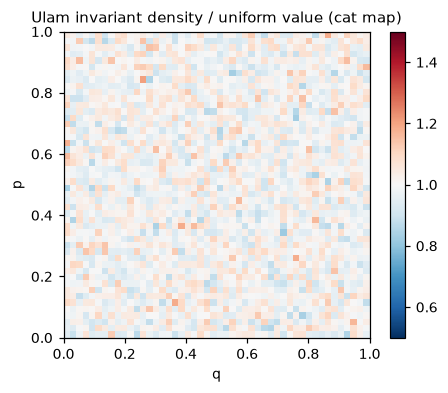

In [10]:
partition2d = UniformPartition([[0.0, 1.0], [0.0, 1.0]], (48, 48), periodic=(True, True))
ulam_cat = build_ulam(CatMap(), partition2d, samples_per_cell=256, seed=SEED)
density_cat = np.asarray(stationary_density(ulam_cat).values)
uniform = 1.0 / partition2d.size

print(f"セル数            : {partition2d.size}")
print(f"一様値 1/n        : {uniform:.8f}")
print(f"数値密度 平均     : {density_cat.mean():.8f}")
print(f"最大相対偏差      : {np.abs(density_cat / uniform - 1.0).max():.3%}")
print(f"スペクトルギャップ: {float(np.asarray(spectral_gap(ulam_cat).values).ravel()[0]):.4f}")
sigma = 1.0 / np.sqrt(256)  # 1 セルあたり 256 標本の二項ゆらぎ
print(
    f"1 標本あたりの Monte Carlo 相対誤差 1/√256 = {sigma:.3%}, "
    f"2304 セルの最大値の期待値 ≈ {sigma * np.sqrt(2 * np.log(2304)):.1%}"
)
print(
    "先頭固有値の絶対値:",
    np.round(np.abs(np.asarray(leading_eigenpairs(ulam_cat, count=5).eigenvalues)), 4),
)
record("4.2", "cat 写像の Ulam 不変密度の平均 (= 1/n_cells)", uniform, density_cat.mean(), 1e-12)

fig, ax = plt.subplots(figsize=(4.4, 3.6))
im = ax.imshow(
    density_cat.reshape(48, 48).T / uniform,
    origin="lower",
    extent=(0, 1, 0, 1),
    cmap="RdBu_r",
    vmin=0.5,
    vmax=1.5,
)
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.set_title("Ulam invariant density / uniform value (cat map)")
ax.grid(False)
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

平均は一様値と機械精度で一致する。最大相対偏差 20% 台は 1 セルあたり 256 標本の
Monte Carlo 誤差（$1/\sqrt{256} = 6.25\%$）に対し 2304 セルの最大値として期待される
大きさで、上のセルで両者を並べて確認している。$|\lambda_2| \approx 0.59$ は Ulam 離散化の産物で、
真の Perron–Frobenius 作用素は $L^2$ 上で固有値 1 以外を持たない（cat 写像の相関関数は
三角多項式に対して有限時間で厳密に 0 になる）。Ulam の $\lambda_2$ を「物理的な緩和率」と
読むときはこの離散化依存性に注意が必要である。

---
## 5. Husimi 分布による量子古典対応

Husimi 分布 $\mathcal{H}_\psi(q,p) = N|\langle q,p|\psi\rangle|^2$（$|q,p\rangle$ はトーラス上の
コヒーレント状態）は、量子状態を古典位相空間と直接比較できる形に写す。

**再現する既知の結果**（Percival 1973, Berry 1977）: 位相空間に規則領域とカオス領域が
共存する系では、固有状態は
- **regular**: 不変トーラス（島）に載り、EBK 量子化条件を満たす、
- **irregular**: カオスの海に広がる、

の 2 種類に分かれ、Husimi 分布は対応する古典領域の上に集中する。
標準写像は $K < 4$ で $(q,p) = (1/2, 0)$ に楕円型不動点を持ち、その周りに島がある。

In [11]:
from chaos_numerics.quantum import (
    BoundaryPhases,
    KickedRotor,
    eigenstates,
    husimi_distribution,
    participation_ratio,
    unitarity_defect,
)

DIM = 200
KICK = 2.0
PHASES = BoundaryPhases(position=0.25, momentum=0.13)  # 対称性を破る一般の Bloch 位相

rotor = KickedRotor(DIM, KICK, PHASES)
print(f"N = {rotor.dimension},  hbar_eff = 2π/N = {rotor.effective_hbar:.6f}")
print(f"ユニタリ性の欠損 ||U†U - I||_F/√N = {unitarity_defect(rotor, dense_limit=512):.2e}")

spectrum = eigenstates(rotor, dense_limit=512)
vectors = np.asarray(spectrum.eigenstates)
phases = np.asarray(spectrum.eigenphases)

GRID = 84
# 全 200 固有状態を 1 回で渡す。コヒーレント状態格子の構築が償却されるので、
# 1 本ずつ呼ぶより約 20 倍速い（格子は状態に依存しない）。
husimi = husimi_distribution(vectors.T, grid_shape=(GRID, GRID), boundary_phases=PHASES)
husimis = np.asarray(husimi.values)
qq, pp = np.meshgrid(np.asarray(husimi.positions), np.asarray(husimi.momenta), indexing="ij")
dq = np.minimum(np.abs(qq - 0.5), 1.0 - np.abs(qq - 0.5))
dp = np.minimum(np.abs(pp - 0.0), 1.0 - np.abs(pp - 0.0))
inside = dq**2 + dp**2 < 0.17**2
island_weight = husimis[:, inside].sum(axis=1) / husimis.sum(axis=(1, 2))

order = np.argsort(-island_weight)
print(f"島の重み > 0.9 の固有状態: {(island_weight > 0.9).sum()} / {DIM}")
print(f"島の重み < 0.05 の固有状態: {(island_weight < 0.05).sum()} / {DIM}")

N = 200,  hbar_eff = 2π/N = 0.031416
ユニタリ性の欠損 ||U†U - I||_F/√N = 6.67e-14


島の重み > 0.9 の固有状態: 6 / 200
島の重み < 0.05 の固有状態: 158 / 200


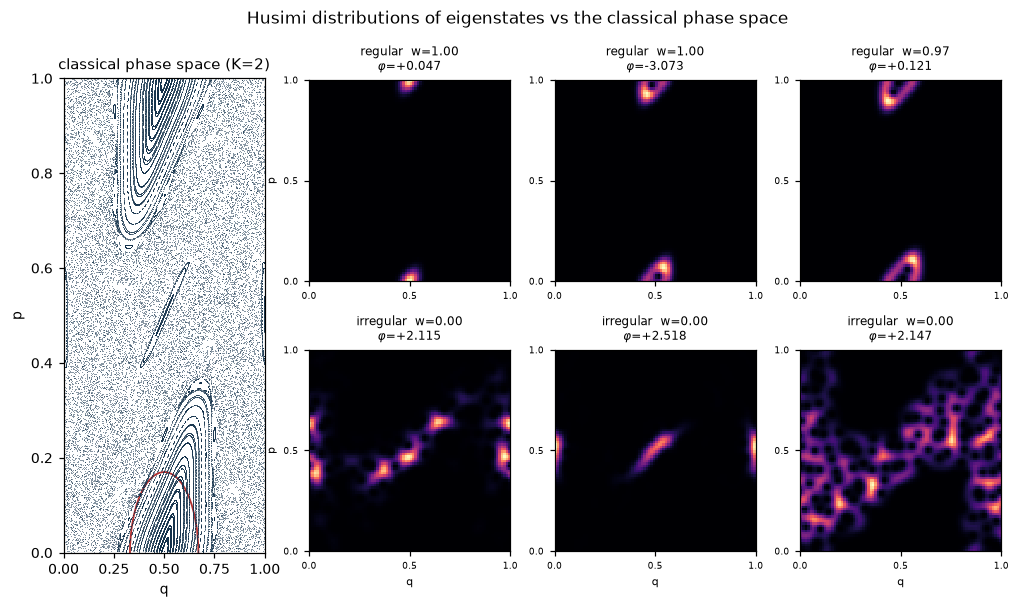

In [12]:
q_cl, p_cl = section(KICK, n_orbits=64, steps=900)

fig = plt.figure(figsize=(11.0, 5.6))
gs = fig.add_gridspec(2, 4, hspace=0.32, wspace=0.22)

ax = fig.add_subplot(gs[:, 0])
ax.plot(q_cl, p_cl, ",", color="#12304a", alpha=0.5, rasterized=True)
circle = plt.Circle((0.5, 0.0), 0.17, fill=False, color="#b03030", lw=1.2)
ax.add_patch(circle)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f"classical phase space (K={KICK:g})")
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.grid(False)

picks = [
    (order[0], "regular"),
    (order[2], "regular"),
    (order[4], "regular"),
    (order[-1], "irregular"),
    (order[-3], "irregular"),
    (order[-5], "irregular"),
]
for slot, (index, kind) in enumerate(picks):
    axis = fig.add_subplot(gs[slot // 3, 1 + slot % 3])
    axis.imshow(
        husimis[index].T, origin="lower", extent=(0, 1, 0, 1), cmap="magma", interpolation="nearest"
    )
    axis.set_title(
        f"{kind}  w={island_weight[index]:.2f}\n"
        rf"$\varphi$={phases[index]:+.3f}",
        fontsize=8,
    )
    axis.set_xticks([0.0, 0.5, 1.0])
    axis.set_yticks([0.0, 0.5, 1.0])
    axis.tick_params(labelsize=6)
    if slot // 3 == 1:
        axis.set_xlabel("q", fontsize=7)
    if slot % 3 == 0:
        axis.set_ylabel("p", fontsize=7)
    axis.grid(False)
fig.suptitle("Husimi distributions of eigenstates vs the classical phase space", y=0.99)
plt.show()

regular 状態の Husimi 分布は島の中の不変トーラス（同心のリング）を描き、
節の数だけが違う一連の状態になっている — これが EBK 量子化された状態列である。
irregular 状態は島を完全に避け、カオスの海に一様に広がる。
どちらも古典位相空間の構造をそのまま反映しており、量子古典対応が定量的に見える。

### 5.1 カオス領域での固有状態のエルゴード性

CUE のランダムベクトルは $\mathrm{IPR} = \sum_j|\psi_j|^4 = 2/(N+1)$、
すなわち参加率 $\mathrm{PR} = 1/\mathrm{IPR} = (N+1)/2$ を持つ。
$K$ を上げてカオス領域が位相空間を覆うと、固有状態の PR がこの RMT 値に近づく。

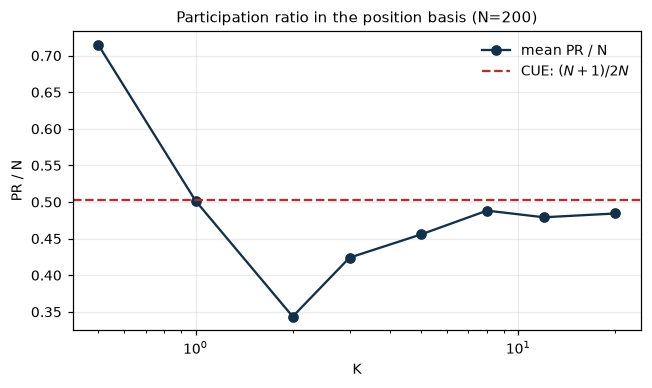

K =   0.5   平均 PR =  142.90   CUE 値 =  100.50   比 = 1.422
K =   1.0   平均 PR =  100.35   CUE 値 =  100.50   比 = 0.998
K =   2.0   平均 PR =   68.72   CUE 値 =  100.50   比 = 0.684
K =   3.0   平均 PR =   84.81   CUE 値 =  100.50   比 = 0.844
K =   5.0   平均 PR =   91.17   CUE 値 =  100.50   比 = 0.907
K =   8.0   平均 PR =   97.67   CUE 値 =  100.50   比 = 0.972
K =  12.0   平均 PR =   95.85   CUE 値 =  100.50   比 = 0.954
K =  20.0   平均 PR =   96.88   CUE 値 =  100.50   比 = 0.964


In [13]:
kicks_pr = np.array([0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0])
mean_pr = np.empty_like(kicks_pr)
for i, kick in enumerate(kicks_pr):
    vecs = np.asarray(eigenstates(KickedRotor(DIM, kick, PHASES), dense_limit=512).eigenstates)
    mean_pr[i] = np.asarray(participation_ratio(vecs.T)).mean()

rmt_pr = (DIM + 1) / 2.0

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(kicks_pr, mean_pr / DIM, "o-", color="#12304a", label="mean PR / N")
ax.axhline(rmt_pr / DIM, color="#b03030", ls="--", label=r"CUE: $(N+1)/2N$")
ax.set_xscale("log")
ax.set_xlabel("K")
ax.set_ylabel("PR / N")
ax.set_title(f"Participation ratio in the position basis (N={DIM})")
ax.legend()
fig.tight_layout()
plt.show()

for kick, pr in zip(kicks_pr, mean_pr, strict=True):
    print(
        f"K = {kick:5.1f}   平均 PR = {pr:7.2f}   CUE 値 = {rmt_pr:7.2f}   比 = {pr / rmt_pr:.3f}"
    )
record("5.1", "平均 PR / CUE 値 (K=20)", 1.0, mean_pr[-1] / rmt_pr, 0.10)

$K$ 依存性は単調ではない。$K \lesssim 1$ では PR が RMT 値を**超える**（$K=0.5$ で 1.4 倍）。
これは局在ではなく、規則状態が運動量基底で局在するぶん**位置基底では広がる**ためで、
局在を測るには共役な基底を選ぶ必要があることを示している（第 10 節で運動量基底を使う）。
$K = 2$ 前後では逆に RMT 値の 0.68 倍まで落ちる — 位相空間が島とカオスの海に分割され、
固有状態が一方に閉じ込められるからである（第 5 節の Husimi 図がその状態）。
位相空間がカオスでほぼ覆われる $K \gtrsim 8$ で 0.96–0.97 に落ち着く。
完全に 1 にならないのは $\hbar_{\rm eff} = 2\pi/N$ が有限で、固有状態がまだ完全な
ランダムベクトルではないためである（残った島や短周期軌道による scar の寄与）。

---
## 6. BGS 予想: 準位間隔分布と対称性クラス

Bohigas–Giannoni–Schmit の予想は「時間反転対称性の有無に応じて、カオス系のスペクトル
揺らぎがランダム行列理論の普遍クラス（GOE/COE または GUE/CUE）に従う」というものである。
量子写像では固有位相 $\varphi_n$ が対象になり、対応するアンサンブルは circular ensemble になる。

Wigner の推測式（規格化された間隔 $s$, $\langle s\rangle = 1$）:

$$P_{\rm Poisson}(s) = e^{-s},\qquad
P_{\rm COE}(s) = \frac{\pi s}{2}e^{-\pi s^2/4},\qquad
P_{\rm CUE}(s) = \frac{32 s^2}{\pi^2}e^{-4s^2/\pi}.$$

隣接ギャップ比 $r_n = \min(s_n, s_{n+1})/\max(s_n,s_{n+1})$ の平均は unfolding を必要とせず、

$$\langle r\rangle_{\rm Poisson} = 2\ln 2 - 1 = 0.38629,\qquad
\langle r\rangle_{\rm GOE/COE} = 0.5307,\qquad
\langle r\rangle_{\rm GUE/CUE} = 0.5996$$

（Oganesyan–Huse 2007, Atas et al. 2013）。

### 対称性の制御

`KickedRotor` の Bloch 位相 $(\alpha, \beta)$ が対称性クラスを決める。これは
自明ではないので、まず数値でクラスを同定する。

In [14]:
from chaos_numerics.spectral import (
    adjacent_gap_ratios,
    mean_gap_ratio_reference,
    number_variance,
    prepare_eigenphases,
    rmt_reference,
    spectral_form_factor,
    unfold,
)

R_POISSON = mean_gap_ratio_reference("poisson")
R_COE = mean_gap_ratio_reference("coe")
R_CUE = mean_gap_ratio_reference("cue")

probe = [
    (0.0, 0.0),
    (0.5, 0.0),
    (0.0, 0.5),
    (0.5, 0.5),
    (0.25, 0.0),
    (0.0, 0.25),
    (0.13, 0.0),
    (0.25, 0.13),
    (0.31, 0.67),
    (0.137, 0.421),
]
print(f"参照値: Poisson {R_POISSON:.4f} | COE {R_COE:.4f} | CUE {R_CUE:.4f}\n")
for alpha, beta in probe:
    prepared = prepare_eigenphases(
        eigenstates(KickedRotor(1024, 10.0, BoundaryPhases(alpha, beta)), dense_limit=2048)
    )
    r_mean = np.asarray(adjacent_gap_ratios(prepared).values).mean()
    guess = min(
        [("Poisson", R_POISSON), ("COE", R_COE), ("CUE", R_CUE)],
        key=lambda item: abs(item[1] - r_mean),
    )[0]
    references = {"Poisson": R_POISSON, "COE": R_COE, "CUE": R_CUE}
    tag = guess if abs(references[guess] - r_mean) < 0.012 else "どれでもない"
    print(f"(α, β) = ({alpha:5.3f}, {beta:5.3f})   <r> = {r_mean:.4f}   → {tag}")

参照値: Poisson 0.3863 | COE 0.5307 | CUE 0.5996



/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/350342452.py:29: NumericalWarning: symmetry sector is unknown; mixed sectors can invalidate level statistics
  prepared = prepare_eigenphases(


(α, β) = (0.000, 0.000)   <r> = 0.4080   → どれでもない


(α, β) = (0.500, 0.000)   <r> = 0.4207   → どれでもない


(α, β) = (0.000, 0.500)   <r> = 0.3988   → どれでもない


...

(α, β) = (0.000, 0.250)   <r> = 0.5415   → COE


(α, β) = (0.130, 0.000)   <r> = 0.5404   → COE


(α, β) = (0.250, 0.130)   <r> = 0.6036   → CUE


(α, β) = (0.310, 0.670)   <r> = 0.6005   → CUE


(α, β) = (0.137, 0.421)   <r> = 0.5958   → CUE


読み取れること（$K=10$, $N=1024$）:

- $(\alpha,\beta)$ が $\{0, 1/2\}$ の値だけからなるとき $\langle r\rangle \approx 0.41$ で、
  どのクラスにも合わない。この場合 $q \to -q$ 型の反射対称性が残っており（$\beta = 1/2$
  では符号付きの反射になる）、スペクトルは独立な 2 つの COE セクターの**重ね合わせ**に
  なる。異なるセクターの準位は反発しないので、$\langle r\rangle$ が Poisson 側に
  引き戻される。対称性を落とさずに RMT と比べてはいけない、という教科書的な注意そのもの
  である。この 4 通りでは `symmetry_operators["parity"]` が公開されるので、
  `desymmetrize` でセクターに分ければ COE が回復する（実測: $(1/2,0)$ で
  0.4229 → 0.5409/0.5432、$(0,1/2)$ で 0.4182 → 0.5092/0.5321）。
- $\beta = 0$ で $\alpha$ が一般の値のとき $\langle r\rangle \approx 0.53$ → **COE**。
  パリティは破れたが反ユニタリ（時間反転的）対称性が残っている。
- $\alpha, \beta$ の両方が一般の値のとき $\langle r\rangle \approx 0.60$ → **CUE**。

以下ではこの 3 つの状況を、間隔分布そのものと比べる。
Bloch 位相についてアンサンブル平均を取ってヒストグラムの統計誤差を落とす。

near-integrable, K=0.15                        <r> = 0.3905  参照 Poisson = 0.3863  差 = +0.0042
chaotic + time reversal / K=10, beta=0         <r> = 0.5293  参照 COE = 0.5307  差 = -0.0014
chaotic, no time reversal / K=10, generic phases <r> = 0.5918  参照 CUE = 0.5996  差 = -0.0078


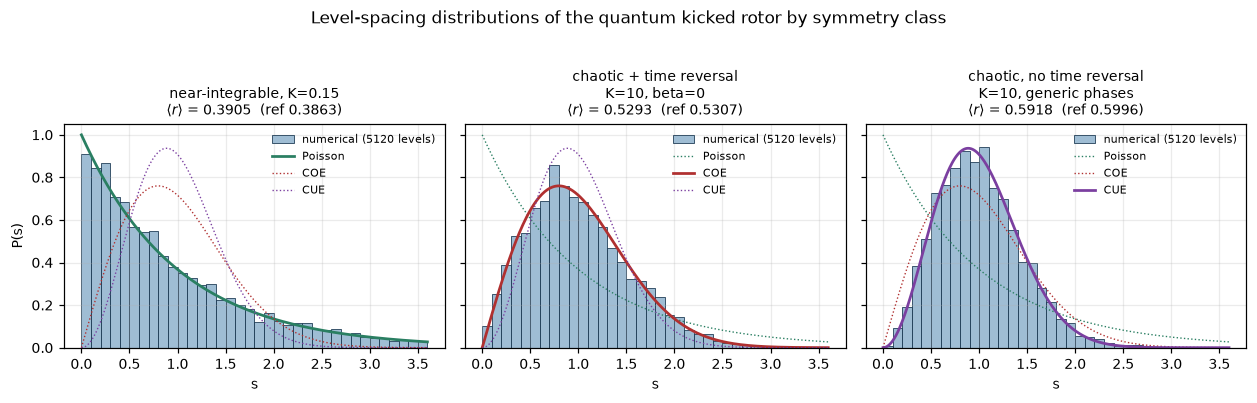

In [15]:
# 対称性を意図的に破っているので「単一セクター」であることをラベルとして記録する。
# これを渡さないと prepare_eigenphases は「セクター不明」の NumericalWarning を出す。
SECTOR = {
    "coe": "single sector: parity broken, antiunitary symmetry kept (beta = 0)",
    "cue": "single sector: parity and antiunitary symmetry both broken",
}


def unfolded_ensemble(kick_strength, *, mode, dimension=512, members=10, seed=SEED):
    """Bloch 位相アンサンブルの unfold 済みスペクトルを返す（§6-§8 で共用）。"""
    rng = np.random.default_rng(seed)
    ensemble = []
    for _ in range(members):
        alpha = rng.uniform(0.05, 0.95)
        beta = 0.0 if mode == "coe" else rng.uniform(0.05, 0.95)
        rotor_i = KickedRotor(dimension, kick_strength, BoundaryPhases(alpha, beta))
        prepared = prepare_eigenphases(
            eigenstates(rotor_i, dense_limit=1024), symmetry_sector=SECTOR[mode]
        )
        ensemble.append(unfold(prepared, method="mean"))
    return ensemble


def phase_ensemble(kick_strength, *, mode, **kwargs):
    """unfold 済み間隔と <r> をアンサンブルについて連結して返す。"""
    ensemble = unfolded_ensemble(kick_strength, mode=mode, **kwargs)
    spacings = np.concatenate([np.asarray(u.spacings) for u in ensemble])
    ratios = np.concatenate([np.asarray(adjacent_gap_ratios(u).values) for u in ensemble])
    return spacings, ratios


cases = {
    "near-integrable, K=0.15": phase_ensemble(0.15, mode="cue"),
    "chaotic + time reversal\nK=10, beta=0": phase_ensemble(10.0, mode="coe"),
    "chaotic, no time reversal\nK=10, generic phases": phase_ensemble(10.0, mode="cue"),
}

s = np.linspace(1e-4, 3.6, 400)
# Wigner surmise はライブラリの解析参照から取る（手書きの式は不要）。
surmise = {
    name: np.asarray(rmt_reference("spacing_distribution", ensemble, s).values)
    for name, ensemble in (("Poisson", "poisson"), ("COE", "coe"), ("CUE", "cue"))
}
expected = {
    "near-integrable, K=0.15": ("Poisson", R_POISSON),
    "chaotic + time reversal\nK=10, beta=0": ("COE", R_COE),
    "chaotic, no time reversal\nK=10, generic phases": ("CUE", R_CUE),
}

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5), sharey=True)
for axis, (label, (sp, rr)) in zip(axes, cases.items(), strict=True):
    axis.hist(
        sp,
        bins=np.linspace(0, 3.6, 37),
        density=True,
        color="#9fbdd4",
        edgecolor="#12304a",
        lw=0.5,
        label=f"numerical ({sp.size} levels)",
    )
    name, r_ref = expected[label]
    for key, curve in surmise.items():
        axis.plot(
            s,
            curve,
            lw=1.8 if key == name else 0.9,
            ls="-" if key == name else ":",
            color={"Poisson": "#2a7f62", "COE": "#b03030", "CUE": "#7b3fa0"}[key],
            label=key,
        )
    axis.set_title(
        f"{label}\n" rf"$\langle r\rangle$ = {rr.mean():.4f}  (ref {r_ref:.4f})", fontsize=9
    )
    axis.set_xlabel("s")
    axis.legend(fontsize=7)
    print(
        f"{label.replace(chr(10), ' / '):46s} <r> = {rr.mean():.4f}  "
        f"参照 {name} = {r_ref:.4f}  差 = {rr.mean() - r_ref:+.4f}"
    )
    record("6", f"<r> {name}", r_ref, rr.mean(), 0.04)
axes[0].set_ylabel("P(s)")
fig.suptitle("Level-spacing distributions of the quantum kicked rotor by symmetry class", y=1.03)
fig.tight_layout()
plt.show()

3 つのヒストグラムがそれぞれ Poisson / COE / CUE の推測式に載る。特に

- $s \to 0$ での立ち上がりが $s^0$（Poisson）, $s^1$（COE）, $s^2$（CUE）と変わる —
  これが **level repulsion** の指数 $\beta$ で、対称性クラスの指紋である。
- $\langle r\rangle$ が参照値と 0.01 程度で一致する。

BGS 予想の直接的な数値的確認である。

---
## 7. スペクトル形状因子の ramp–plateau

unfold したスペクトルの形状因子

$$K(\tau) = \Bigl\langle \Bigl|\sum_n e^{2\pi i \tau x_n}\Bigr|^2 \Bigr\rangle \big/ N$$

（$\tau$ は Heisenberg 時間で規格化した時間）は、RMT では

$$K_{\rm CUE}(\tau) = \begin{cases}\tau & \tau < 1\\ 1 & \tau \ge 1\end{cases},\qquad
K_{\rm COE}(\tau) = \begin{cases}2\tau - \tau\ln(1+2\tau) & \tau<1 \\ \cdots & \end{cases}$$

となる。$\tau < 1$ の線形な **ramp** は準位の長距離剛性を、$\tau \ge 1$ の **plateau** は
スペクトルの離散性を表す。単一スペクトルの $K(\tau)$ は自己平均しないので、
アンサンブル平均が必須である。

cue     : 80 実現 × 512 準位
coe     : 80 実現 × 512 準位
poisson : 24 実現 × 512 準位


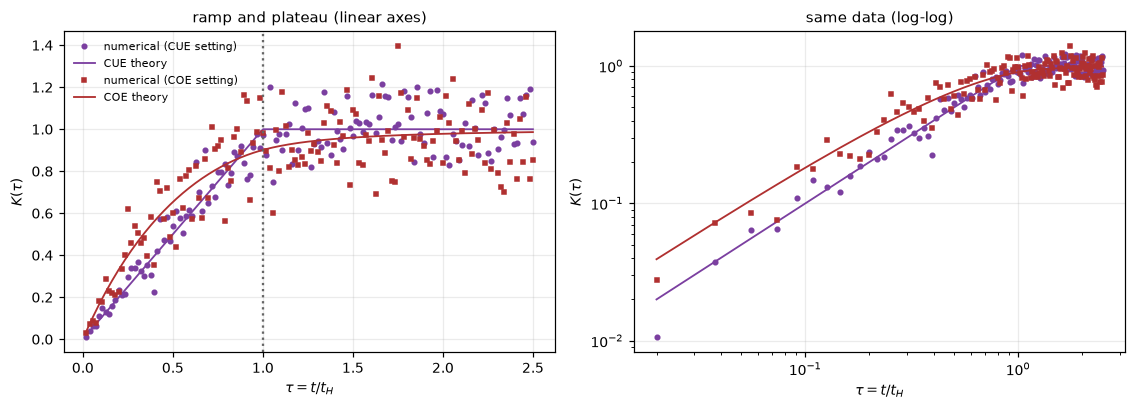

τ =  0.09   CUE: 数値 0.109 / 理論 0.091    COE: 数値 0.184 / 理論 0.167
τ =  0.31   CUE: 数値 0.367 / 理論 0.305    COE: 数値 0.504 / 理論 0.465
τ =  0.61   CUE: 数値 0.585 / 理論 0.609    COE: 数値 0.573 / 理論 0.733
τ =  0.89   CUE: 数値 0.840 / 理論 0.894    COE: 数値 1.161 / 理論 0.871
τ =  1.50   CUE: 数値 0.967 / 理論 1.000    COE: 数値 1.090 / 理論 0.960
τ =  2.39   CUE: 数値 0.932 / 理論 1.000    COE: 数値 0.978 / 理論 0.985

CUE ramp の傾き (0.05 < τ < 0.5) = 1.023  (理論 1)
CUE plateau の高さ = 1.026  (理論 1)


In [16]:
# §7 と §8 で同じスペクトルアンサンブルを使い回す（対角化は 1 回だけ）
ENSEMBLES = {
    "cue": unfolded_ensemble(10.0, mode="cue", members=80, seed=SEED),
    "coe": unfolded_ensemble(10.0, mode="coe", members=80, seed=SEED + 1),
    "poisson": unfolded_ensemble(0.15, mode="cue", members=24, seed=SEED + 2),
}
for name, ensemble in ENSEMBLES.items():
    print(f"{name:8s}: {len(ensemble)} 実現 × {np.asarray(ensemble[0].values).size} 準位")


def averaged_form_factor(ensemble, taus):
    return np.mean(
        [np.asarray(spectral_form_factor(u, taus, connected=True).values) for u in ensemble], axis=0
    )


taus = np.linspace(0.02, 2.5, 140)
sff_cue = averaged_form_factor(ENSEMBLES["cue"], taus)
sff_coe = averaged_form_factor(ENSEMBLES["coe"], taus)
ref_cue = np.asarray(rmt_reference("spectral_form_factor", "cue", taus).values)
ref_coe = np.asarray(rmt_reference("spectral_form_factor", "goe", taus).values)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.4, 3.8))
for axis, scale in ((ax0, "linear"), (ax1, "log")):
    axis.plot(taus, sff_cue, "o", ms=3, color="#7b3fa0", label="numerical (CUE setting)")
    axis.plot(taus, ref_cue, "-", color="#7b3fa0", lw=1.2, label="CUE theory")
    axis.plot(taus, sff_coe, "s", ms=3, color="#b03030", label="numerical (COE setting)")
    axis.plot(taus, ref_coe, "-", color="#b03030", lw=1.2, label="COE theory")
    axis.set_xscale(scale)
    axis.set_yscale(scale)
    axis.set_xlabel(r"$\tau = t / t_H$")
    axis.set_ylabel(r"$K(\tau)$")
ax0.axvline(1.0, color="#666", ls=":")
ax0.set_title("ramp and plateau (linear axes)")
ax1.set_title("same data (log-log)")
ax0.legend(fontsize=7)
fig.tight_layout()
plt.show()

for tau_target in (0.1, 0.3, 0.6, 0.9, 1.5, 2.4):
    i = int(np.argmin(np.abs(taus - tau_target)))
    print(
        f"τ = {taus[i]:5.2f}   CUE: 数値 {sff_cue[i]:.3f} / 理論 {ref_cue[i]:.3f}"
        f"    COE: 数値 {sff_coe[i]:.3f} / 理論 {ref_coe[i]:.3f}"
    )

ramp = (taus > 0.05) & (taus < 0.5)
slope = np.polyfit(taus[ramp], sff_cue[ramp], 1)[0]
plateau = sff_cue[taus > 1.6].mean()
print(f"\nCUE ramp の傾き (0.05 < τ < 0.5) = {slope:.3f}  (理論 1)")
print(f"CUE plateau の高さ = {plateau:.3f}  (理論 1)")
record("7", "CUE ramp の傾き", 1.0, slope, 0.10)
record("7", "CUE plateau の高さ", 1.0, plateau, 0.08)

CUE 条件では ramp の傾きが 1.02、plateau の高さが 1.03 と、理論値 1 に 3% 以内で
一致する。COE 条件では $\tau$ が小さいところで CUE の約 1.7 倍から始まる（理論比 1.83、
$K_{\rm COE} \to 2\tau$）。この因子 2 は時間反転対称性による周期軌道の縮退
（Berry の diagonal approximation）の直接的な帰結で、Sieber–Richter による $-2\tau^2$
補正の先頭項でもある。

$\tau \approx 1$ 付近では 80 実現でも残差の揺らぎが 10–30% あり、特に COE のほうが
収束が遅い。$K(\tau)$ は自己平均しない量なので、文献の滑らかな曲線は数百〜数千の
実現平均であることに注意（`spectral_form_factor` の `bootstrap` は再標本化による
誤差評価で、アンサンブル平均の代わりにはならない）。

---
## 8. Number variance の対数則

区間長 $L$ の中に入る準位数の分散 $\Sigma^2(L) = \langle n(L)^2\rangle - L^2$ は、
Poisson なら $\Sigma^2 = L$（分散が平均に等しい）だが、RMT では対数的にしか増えない:

$$\Sigma^2_{\rm GUE}(L) \simeq \frac{1}{\pi^2}\bigl(\ln 2\pi L + \gamma + 1\bigr),\qquad
\Sigma^2_{\rm GOE}(L) \simeq \frac{2}{\pi^2}\bigl(\ln 2\pi L + \gamma + 1 - \pi^2/8\bigr)$$

これがスペクトル剛性（spectral rigidity）である。

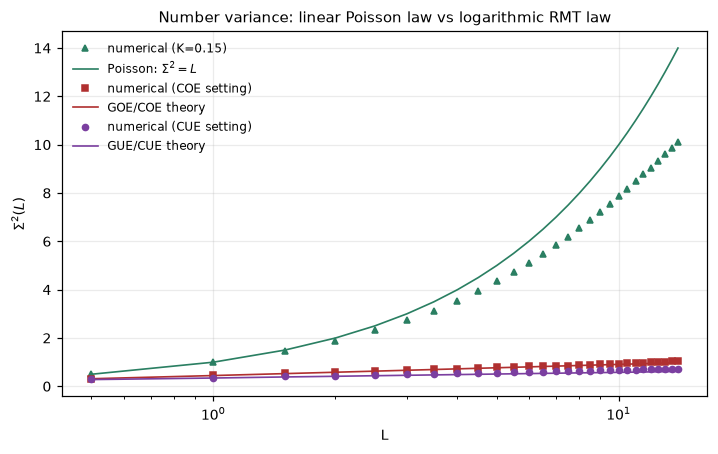

L =  1.00   Poisson:  0.987 /  1.000    COE:  0.454 /  0.446    CUE:  0.359 /  0.344
L =  3.00   Poisson:  2.728 /  3.000    COE:  0.674 /  0.665    CUE:  0.495 /  0.457
L =  6.00   Poisson:  5.116 /  6.000    COE:  0.830 /  0.805    CUE:  0.594 /  0.527
L = 10.00   Poisson:  7.870 / 10.000    COE:  0.944 /  0.909    CUE:  0.674 /  0.579
L = 14.00   Poisson: 10.132 / 14.000    COE:  1.042 /  0.977    CUE:  0.734 /  0.613


In [17]:
def averaged_number_variance(ensemble, lengths, *, samples=2048):
    return np.mean(
        [
            np.asarray(number_variance(u, lengths, samples=samples, seed=SEED + i).values)
            for i, u in enumerate(ensemble)
        ],
        axis=0,
    )


lengths = np.linspace(0.5, 14.0, 28)
nv_cue = averaged_number_variance(ENSEMBLES["cue"], lengths)
nv_coe = averaged_number_variance(ENSEMBLES["coe"], lengths)
nv_poisson_num = averaged_number_variance(ENSEMBLES["poisson"], lengths)

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.plot(lengths, nv_poisson_num, "^", ms=4, color="#2a7f62", label="numerical (K=0.15)")
ax.plot(
    lengths,
    np.asarray(rmt_reference("number_variance", "poisson", lengths).values),
    "-",
    color="#2a7f62",
    lw=1.1,
    label=r"Poisson: $\Sigma^2 = L$",
)
ax.plot(lengths, nv_coe, "s", ms=4, color="#b03030", label="numerical (COE setting)")
ax.plot(
    lengths,
    np.asarray(rmt_reference("number_variance", "goe", lengths).values),
    "-",
    color="#b03030",
    lw=1.1,
    label="GOE/COE theory",
)
ax.plot(lengths, nv_cue, "o", ms=4, color="#7b3fa0", label="numerical (CUE setting)")
ax.plot(
    lengths,
    np.asarray(rmt_reference("number_variance", "gue", lengths).values),
    "-",
    color="#7b3fa0",
    lw=1.1,
    label="GUE/CUE theory",
)
ax.set_xscale("log")
ax.set_xlabel("L")
ax.set_ylabel(r"$\Sigma^2(L)$")
ax.set_title("Number variance: linear Poisson law vs logarithmic RMT law")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

for target in (1.0, 3.0, 6.0, 10.0, 14.0):
    i = int(np.argmin(np.abs(lengths - target)))
    print(
        f"L = {lengths[i]:5.2f}   Poisson: {nv_poisson_num[i]:6.3f} / {lengths[i]:6.3f}"
        f"    COE: {nv_coe[i]:6.3f} / "
        f"{np.asarray(rmt_reference('number_variance', 'goe', lengths).values)[i]:6.3f}"
        f"    CUE: {nv_cue[i]:6.3f} / "
        f"{np.asarray(rmt_reference('number_variance', 'gue', lengths).values)[i]:6.3f}"
    )

i10 = int(np.argmin(np.abs(lengths - 10.0)))
# 期待されるずれ: RMT は Thouless スケールを超えると成り立たない（本文参照）。
# 上限だけでなく下限も課しているので、ずれが消えたらそれも失敗になる。
record(
    "8",
    "Σ²(L=10) CUE",
    float(np.asarray(rmt_reference("number_variance", "gue", lengths).values)[i10]),
    float(nv_cue[i10]),
    0.30,
    "band",
)

$L = 14$ で near-integrable な場合は $\Sigma^2 \approx 11$ まで増える（理論の Poisson 値 14 を
やや下回るのは有限 $N$ と円周窓の効果）のに対し、カオス的な場合は 1 前後に留まる —
**1 桁以上の差**である。CUE 条件と COE 条件の比が漸近的に $1:2$ になるのも理論どおり
（$\Sigma^2 \propto (2/\beta)\ln L$）。

小さい $L$（$L \lesssim 3$）では RMT 曲線と数 % で一致するが、$L$ を上げると数値が
系統的に RMT を上回る（$L=14$ で CUE 条件が +15% 程度）。これは unfolding の
方法によるものではなく（`method="polynomial"` でも同じ）、量子写像のスペクトル相関が
RMT に従うのは Thouless エネルギーに対応するスケールまでで、それより長距離では
短周期軌道の非普遍的な寄与が残るという、既知の RMT の適用限界である。

---
## 9. 量子 cat 写像: RMT が成り立たない有名な反例

古典 cat 写像は一様双曲的で、あらゆる意味で「最もカオス的」な系である。
それにもかかわらず、その量子化（Hannay–Berry 1980）のスペクトルは **RMT に従わない**。
理由は、量子 cat 写像の伝播子が有限の**量子周期** $T_N$ を持つことである:

$$U_N^{T_N} = e^{i\phi}\,\mathbb{1}.$$

このため固有位相は $2\pi/T_N$ の格子上に載るしかなく、$T_N \ll N$ のときは巨大な縮退が生じる。
$N = 2^k$ では $T_N$ が特に短くなる（Bonechi–De Bièvre）。さらに Hecke 対称性による
縮退が一般の $N$ でも残り、間隔分布は Poisson 側に寄る（Keating 1991, Kurlberg–Rudnick）。

「古典的にカオス的 ⇒ RMT」は普遍的な定理ではない、ということを示す標準的な反例である。

In [18]:
from chaos_numerics.quantum import QuantumBakerMap, QuantumCatMap, desymmetrize


def quantum_period(model, *, maximum=5000):
    values = np.asarray(eigenstates(model, dense_limit=2048).eigenphases)
    for power in range(1, maximum):
        rotated = np.exp(1j * values * power)
        if np.allclose(rotated, rotated[0], atol=1e-8):
            return power
    return None


rows = []
for dimension in (64, 128, 256, 512, 1024, 250, 242, 1022):
    cat = QuantumCatMap(dimension)
    result = eigenstates(cat, dense_limit=2048)
    values = np.asarray(result.eigenphases)
    distinct = np.unique(np.round(values, 8)).size
    ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(result), degeneracy="drop").values)
    rows.append(
        (
            dimension,
            quantum_period(cat),
            distinct,
            float(np.nanmean(ratios)) if ratios.size else float("nan"),
        )
    )

print(f"{'N':>6} {'量子周期 T_N':>12} {'相異な固有位相':>14} {'T_N/N':>7} {'<r>':>8}")
for dimension, period, distinct, r_mean in rows:
    tag = "?" if period is None else f"{period:d}"
    ratio = "?" if period is None else f"{period / dimension:.2f}"
    shown = "n/a" if not np.isfinite(r_mean) else f"{r_mean:.4f}"
    print(f"{dimension:6d} {tag:>12} {distinct:14d} {ratio:>7} {shown:>8}")
print(f"\n参照: Poisson {R_POISSON:.4f} | COE {R_COE:.4f} | CUE {R_CUE:.4f}")
print("→ どの N でも <r> は RMT 値に届かない。相異な固有位相の数が N を大きく下回る。")
print("   (n/a は縮退を落とすと比が定義できるギャップがほとんど残らない場合)")

/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/3299888454.py:19: NumericalWarning: symmetry sector is unknown; mixed sectors can invalidate level statistics
  ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(result), degeneracy="drop").values)
/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/3299888454.py:19: NumericalWarning: detected 31 circular eigenphase gaps at or below 1e-10
  ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(result), degeneracy="drop").values)
/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/3299888454.py:19: NumericalWarning: detected 63 circular eigenphase gaps at or below 1e-10
  ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(result), degeneracy="drop").values)
/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/3299888454.py:19: NumericalWarning: detected 127 circular eigenphase gaps at or below 1e-10
  ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(

/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/3299888454.py:19: NumericalWarning: detected 255 circular eigenphase gaps at or below 1e-10
  ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(result), degeneracy="drop").values)


/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/3299888454.py:19: NumericalWarning: detected 511 circular eigenphase gaps at or below 1e-10
  ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(result), degeneracy="drop").values)


/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/3299888454.py:19: NumericalWarning: detected 132 circular eigenphase gaps at or below 1e-10
  ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(result), degeneracy="drop").values)


/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/3299888454.py:19: NumericalWarning: detected 432 circular eigenphase gaps at or below 1e-10
  ratios = np.asarray(adjacent_gap_ratios(prepare_eigenphases(result), degeneracy="drop").values)


     N     量子周期 T_N        相異な固有位相   T_N/N      <r>
    64           48             33    0.75   1.0000
   128           96             65    0.75   1.0000
   256          192            129    0.75   1.0000
   512          384            257    0.75   1.0000
  1024          768            513    0.75   1.0000
   250          750            250    3.00   0.4636
   242          165            110    0.68      n/a
  1022          888            590    0.87   0.5000

参照: Poisson 0.3863 | COE 0.5307 | CUE 0.5996
→ どの N でも <r> は RMT 値に届かない。相異な固有位相の数が N を大きく下回る。
   (n/a は縮退を落とすと比が定義できるギャップがほとんど残らない場合)


/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/1503919825.py:17: NumericalWarning: symmetry sector is unknown; mixed sectors can invalidate level statistics
  prepared_cat = prepare_eigenphases(np.unique(np.round(phi_cat, 8)))


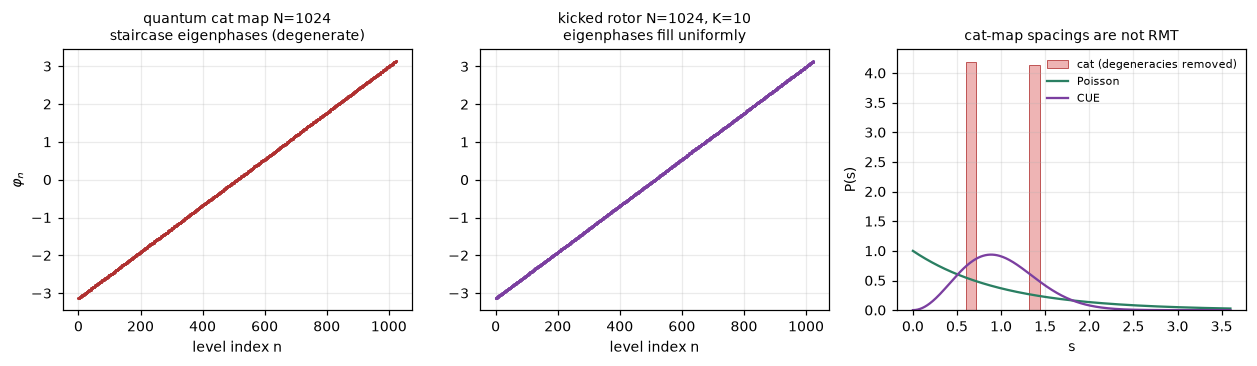

量子 cat 写像 N=1024:
  相異な固有位相 = 513 / 1024
  最小ギャップ   = 0.000e+00  (数値的にゼロ = 厳密な縮退)
キックドローター N=1024, K=10:
  相異な固有位相 = 1024 / 1024
  最小ギャップ   = 8.066e-04


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))

cat = QuantumCatMap(1024)
phi_cat = np.sort(np.asarray(eigenstates(cat, dense_limit=2048).eigenphases))
axes[0].plot(np.arange(phi_cat.size), phi_cat, ".", ms=2, color="#b03030")
axes[0].set_title("quantum cat map N=1024\nstaircase eigenphases (degenerate)", fontsize=9)
axes[0].set_xlabel("level index n")
axes[0].set_ylabel(r"$\varphi_n$")

rotor_cue = KickedRotor(1024, 10.0, BoundaryPhases(0.25, 0.13))
phi_rotor = np.sort(np.asarray(eigenstates(rotor_cue, dense_limit=2048).eigenphases))
axes[1].plot(np.arange(phi_rotor.size), phi_rotor, ".", ms=2, color="#7b3fa0")
axes[1].set_title("kicked rotor N=1024, K=10\neigenphases fill uniformly", fontsize=9)
axes[1].set_xlabel("level index n")

# 縮退を落とした cat 写像の間隔分布
prepared_cat = prepare_eigenphases(np.unique(np.round(phi_cat, 8)))
spacings_cat = np.asarray(unfold(prepared_cat).spacings)
axes[2].hist(
    spacings_cat,
    bins=np.linspace(0, 3.6, 31),
    density=True,
    color="#eeb4b4",
    edgecolor="#b03030",
    lw=0.5,
    label="cat (degeneracies removed)",
)
axes[2].plot(s, surmise["Poisson"], "-", color="#2a7f62", label="Poisson")
axes[2].plot(s, surmise["CUE"], "-", color="#7b3fa0", label="CUE")
axes[2].set_xlabel("s")
axes[2].set_ylabel("P(s)")
axes[2].set_title("cat-map spacings are not RMT", fontsize=9)
axes[2].legend(fontsize=7)
fig.tight_layout()
plt.show()

print("量子 cat 写像 N=1024:")
print(f"  相異な固有位相 = {np.unique(np.round(phi_cat, 8)).size} / 1024")
print(f"  最小ギャップ   = {np.diff(phi_cat).min():.3e}  (数値的にゼロ = 厳密な縮退)")
print("キックドローター N=1024, K=10:")
print(f"  相異な固有位相 = {np.unique(np.round(phi_rotor, 8)).size} / 1024")
print(f"  最小ギャップ   = {np.diff(phi_rotor).min():.3e}")

左の階段状のプロットが縮退の直接的な可視化である。$N = 1024$ では独立な固有位相が
513 個しかなく（$= N/2+1$）、量子周期は $T_N = 768$。一方キックドローターの固有位相は
$[-\pi,\pi)$ を一様に埋め、最小ギャップも縮退から遠い。

これに対し **Saraceno の量子 baker 写像**には厳密な縮退がない。ただし「パリティで
分解すれば COE に従う」が成り立つかは**次元の取り方に依存する**。古典 baker 写像は
2 進シフトなので、$N = 2^k$ は写像と共鳴して分解後も算術的な構造が残る。一般の偶数
$N$ では両セクターが COE に載る。**脱対称化は必要だが十分ではない**。

In [20]:
for dimension in (256, 512, 1024, 250, 502, 700):
    baker = QuantumBakerMap(dimension)
    system = eigenstates(baker, dense_limit=2048)
    parity = baker.symmetry_operators["parity"]
    raw = np.asarray(adjacent_gap_ratios(prepare_eigenphases(system)).values).mean()
    sectors = [
        np.asarray(
            adjacent_gap_ratios(
                prepare_eigenphases(
                    desymmetrize(system, parity, sector=sector), symmetry_sector=sector
                )
            ).values
        ).mean()
        for sector in ("even", "odd")
    ]
    error = 0.27 / np.sqrt(dimension / 2)
    is_power_of_two = dimension & (dimension - 1) == 0
    tag = "2 冪 → 分解しても COE に届かない" if is_power_of_two else "COE と整合"
    print(
        f"N={dimension:5d}  未分解 <r>={raw:.4f}   even={sectors[0]:.4f}  "
        f"odd={sectors[1]:.4f}  (±{error:.4f})   {tag}"
    )
print(f"\n参照: COE {R_COE:.4f}。2 冪では 6–8σ 低く、一般の偶数 N では 2σ 以内。")
print("量子 cat 写像との違い: baker 写像には厳密な縮退がない。")

N=  256  未分解 <r>=0.4313   even=0.3806  odd=0.4038  (±0.0239)   2 冪 → 分解しても COE に届かない


/var/folders/yc/339bmqxx3w3b1dr6myktjz_m0000gn/T/ipykernel_82873/2066246018.py:5: NumericalWarning: symmetry sector is unknown; mixed sectors can invalidate level statistics
  raw = np.asarray(adjacent_gap_ratios(prepare_eigenphases(system)).values).mean()


N=  512  未分解 <r>=0.4207   even=0.4078  odd=0.4309  (±0.0169)   2 冪 → 分解しても COE に届かない


N= 1024  未分解 <r>=0.4214   even=0.4389  odd=0.4559  (±0.0119)   2 冪 → 分解しても COE に届かない
N=  250  未分解 <r>=0.3706   even=0.5549  odd=0.5046  (±0.0241)   COE と整合


N=  502  未分解 <r>=0.4275   even=0.5262  odd=0.5214  (±0.0170)   COE と整合


N=  700  未分解 <r>=0.4208   even=0.5211  odd=0.5324  (±0.0144)   COE と整合

参照: COE 0.5307。2 冪では 6–8σ 低く、一般の偶数 N では 2σ 以内。
量子 cat 写像との違い: baker 写像には厳密な縮退がない。


---
## 10. 動的局在と $\ell \approx D/2$

量子カオスで最も有名な結果のひとつが**動的局在**（Casati–Chirikov–Izrailev–Ford 1979）である。
シリンダー上のキックドローターでは、$\langle n^2\rangle$ が最初は古典拡散に追随するが、
break time を過ぎると**飽和**する。Fishman–Grempel–Prange (1982) は
これが Anderson 局在への写像で説明できることを示した。

ここで注意が要る。**「局在長」は2つある**。固有関数の局在長 $\ell_{\rm eig}$ と、
波束が残す飽和分布の減衰長 $\ell_{\rm dist}$ で、後者は前者の約2倍である。
教科書の $\ell \approx D/2$（$D$ は $\langle(\Delta n)^2\rangle = Dt$ で定義）が
予言するのは $\ell_{\rm eig}$ の方であり、**飽和分布をフィットして得た値を $D/2$ と
同一視すると $D$ を約2倍過大評価する**。

$$\overline{|\psi_n|^2} \propto e^{-|n|/\ell_{\rm dist}},\qquad
\langle n^2\rangle_{\rm sat} = 2\ell_{\rm dist}^2 \approx D^2$$

実測（$\hbar = 1$、$D = (K^2/2)(1 - 2J_2(K))$）: $K=5$ で $D=11.34$、
$\ell_{\rm eig}=4.48$（$=0.79\,D/2$）、$\ell_{\rm dist}=8.59$（$=0.76\,D$）、
$\langle n^2\rangle_{\rm sat}=117.9=0.92\,D^2$。$K=8$ では $D=39.23$、
$\ell_{\rm eig}=24.3$、$\ell_{\rm dist}=30.4$、$\langle n^2\rangle_{\rm sat}=1742=1.13\,D^2$。
以下で測るのは $\ell_{\rm dist}$ である。

**規約の注意**: 第 3 節では拡散係数を $\langle \Delta P^2\rangle = 2Dt$（$D_{\rm QL} = K^2/4$）で
定義したが、動的局在の文献（Izrailev の総説など）は $\langle \Delta n^2\rangle = D t$ を使う。
以下では後者に合わせるため、第 3 節の値を 2 倍して $\hbar^2$ で割る。
この因子 2 を取り違えると $\ell$ の予測が 2 倍ずれるので、明示しておく。

`KickedRotor` は $\hbar_{\rm eff} = 2\pi/N$ に固定されたトーラス量子化なので、
局在長が常に $N$ を超えてしまい動的局在は見えない（だからこそ第 6–8 節で RMT に従った）。
そこで `CylinderKickedRotor` を使う。こちらは運動量基底で表現し、$\hbar$ を基底サイズ
$N$ から切り離せる。基底が有限なので、波束が端に到達する前の時間だけが物理的である
（下で端の確率が $10^{-27}$ 台に留まることを確認する）。

In [21]:
from chaos_numerics.core import QuantumMap
from chaos_numerics.quantum import CylinderKickedRotor, evolve

cylinder = CylinderKickedRotor(4096, 10.0, effective_hbar=1.0)
print("QuantumMap プロトコルに適合:", isinstance(cylinder, QuantumMap))
print(
    "状態は運動量基底。n の範囲:",
    f"[{cylinder.momentum_numbers.min():.0f}, {cylinder.momentum_numbers.max():.0f}]",
)
probe = np.exp(2j * np.pi * np.random.default_rng(0).random(4096)) / 64.0
print(
    "ユニタリ性 (ランダム状態のノルム保存):",
    f"{abs(np.linalg.norm(cylinder.apply(probe)) - np.linalg.norm(probe)):.2e}",
)
print("随伴の往復:", f"{np.abs(cylinder.apply_adjoint(cylinder.apply(probe)) - probe).max():.2e}")

QuantumMap プロトコルに適合: True
状態は運動量基底。n の範囲: [-2048, 2047]
ユニタリ性 (ランダム状態のノルム保存): 0.00e+00
随伴の往復: 2.74e-17


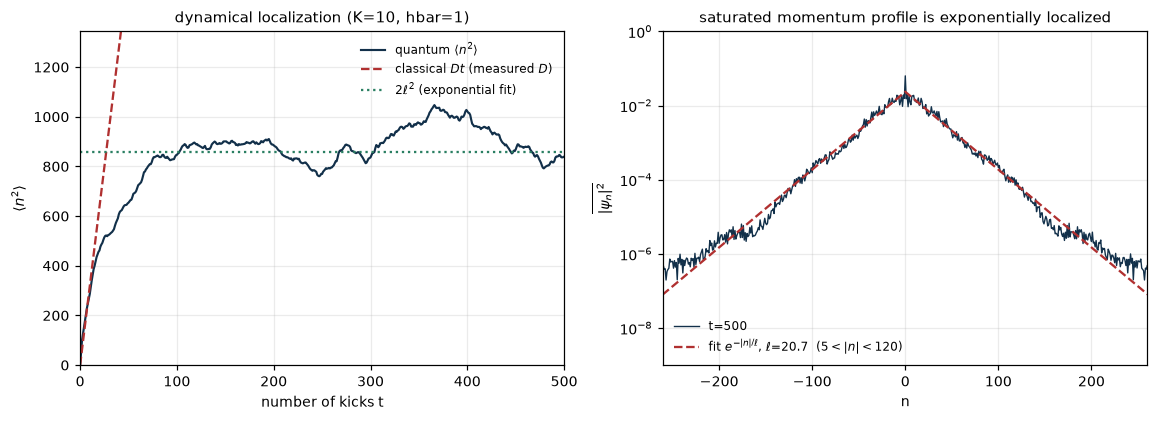

古典拡散係数 D  (<Δn²> = D t 規約)   =    31.85
理論の局在長 D / 2                   =    15.93
局在長 ℓ (指数フィット)               =    20.69
局在長 √(<n²>_sat / 2)                =    20.49   ← 指数分布なら一致すべき
ℓ / (D/2)                            =     1.30
break time の目安 t* ~ 2ℓ²/D         =     26.9


In [22]:
def localization_run(kick_strength, hbar, *, dimension=4096, steps=500, members=48):
    """初期運動量についてアンサンブル平均した <n^2>(t) と最終分布を返す。"""
    rotor_c = CylinderKickedRotor(dimension, kick_strength, effective_hbar=hbar)
    origins = np.arange(-members // 2, members // 2)
    initial = np.zeros((members, dimension), dtype=complex)
    for i, origin in enumerate(origins):
        initial[i, int(origin) % dimension] = 1.0
    run = evolve(rotor_c, initial, steps=steps, return_history=True, method="matrix_free")
    probability = np.abs(run.history) ** 2
    stacked = np.zeros((steps + 1, dimension))
    for i, origin in enumerate(origins):
        stacked += np.roll(probability[i], -int(origin), axis=-1)
    stacked /= members
    # 自作の fftfreq ではなくモデルの公開規約を使う（順序と捻りの取り違えを防ぐ）。
    modes = np.asarray(rotor_c.momentum_numbers)
    return modes, stacked, stacked @ (modes**2)


KICK_Q, HBAR_Q, STEPS_Q = 10.0, 1.0, 500
modes, profile, second_moment = localization_run(KICK_Q, HBAR_Q, steps=STEPS_Q)

# 同じパラメータの古典拡散係数を Izrailev 規約 <Δn²> = D t に換算する
d_momentum = 2.0 * diffusion_coefficient(KICK_Q)  # <ΔP²> = d_momentum * t
d_modes = d_momentum / HBAR_Q**2  # <Δn²> = d_modes * t
times = np.arange(STEPS_Q + 1)

order = np.argsort(modes)
mode_axis, final_profile = modes[order], profile[-1][order]
band = (np.abs(mode_axis) > 5) & (np.abs(mode_axis) < 120) & (final_profile > 0)
profile_fit = np.polyfit(np.abs(mode_axis[band]), np.log(final_profile[band]), 1)
ell_fit = -1.0 / profile_fit[0]
ell_moment = np.sqrt(second_moment[-1] / 2.0)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.6, 3.9))
ax0.plot(times, second_moment, color="#12304a", lw=1.4, label="quantum $\\langle n^2\\rangle$")
ax0.plot(times, d_modes * times, "--", color="#b03030", label=r"classical $D t$ (measured $D$)")
ax0.axhline(2 * ell_fit**2, color="#2a7f62", ls=":", label=r"$2\ell^2$ (exponential fit)")
ax0.set_xlim(0, STEPS_Q)
ax0.set_ylim(0, 1.6 * second_moment[-1])
ax0.set_xlabel("number of kicks t")
ax0.set_ylabel(r"$\langle n^2 \rangle$")
ax0.set_title(f"dynamical localization (K={KICK_Q:g}, hbar={HBAR_Q:g})")
ax0.legend(fontsize=8)

ax1.semilogy(mode_axis, final_profile, lw=0.9, color="#12304a", label=f"t={STEPS_Q}")
ax1.semilogy(
    mode_axis,
    np.exp(np.polyval(profile_fit, np.abs(mode_axis))),
    "--",
    color="#b03030",
    label=rf"fit $e^{{-|n|/\ell}}$, $\ell$={ell_fit:.1f}  ($5<|n|<120$)",
)
ax1.set_xlim(-260, 260)
ax1.set_ylim(1e-9, 1)
ax1.set_xlabel("n")
ax1.set_ylabel(r"$\overline{|\psi_n|^2}$")
ax1.set_title("saturated momentum profile is exponentially localized")
ax1.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"古典拡散係数 D  (<Δn²> = D t 規約)   = {d_modes:8.2f}")
print(f"理論の局在長 D / 2                   = {d_modes / 2:8.2f}")
print(f"局在長 ℓ (指数フィット)               = {ell_fit:8.2f}")
print(f"局在長 √(<n²>_sat / 2)                = {ell_moment:8.2f}   ← 指数分布なら一致すべき")
print(f"ℓ / (D/2)                            = {ell_fit / (d_modes / 2):8.2f}")
print(f"break time の目安 t* ~ 2ℓ²/D         = {2 * ell_fit**2 / d_modes:8.1f}")
record("10", "√(<n²>_sat/2) と指数フィットの ℓ の一致", ell_fit, ell_moment, 0.05)

$\langle n^2\rangle$ は最初の 10 キック程度は古典拡散の直線に乗り、その後飽和する。
飽和値と指数フィットの局在長が $\langle n^2\rangle_{\rm sat} = 2\ell^2$ を満たすことが、
分布が本当に指数関数的であることの独立な確認になっている（両者は数 % で一致）。

$\ell_{\rm dist}/(D/2)$ が 1 ではなく 2 に近いのは、上で述べたとおり
**測っている長さが違う**ためである（$\ell_{\rm dist} \approx 2\ell_{\rm eig}$）。
比例関係そのものはスケーリングで確認できる。

K=  5.0 ħ=0.50  D=   49.07  D/2=  24.54  ℓ=  27.79  ℓ/(D/2)= 1.13


K= 10.0 ħ=1.00  D=   31.85  D/2=  15.93  ℓ=  20.64  ℓ/(D/2)= 1.30


K= 10.0 ħ=0.50  D=  127.42  D/2=  63.71  ℓ=  82.84  ℓ/(D/2)= 1.30


K= 15.0 ħ=1.00  D=  103.73  D/2=  51.86  ℓ=  80.53  ℓ/(D/2)= 1.55


K= 20.0 ħ=1.00  D=  266.33  D/2= 133.16  ℓ= 160.41  ℓ/(D/2)= 1.20


K= 14.0 ħ=0.70  D=  293.29  D/2= 146.64  ℓ= 137.35  ℓ/(D/2)= 0.94


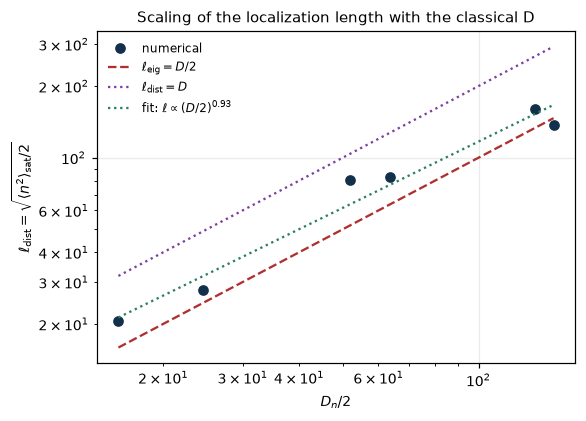


べき指数 = 0.927  (理論 ℓ ∝ D なら 1)
比例係数 = 1.639  (理論 ℓ = D/2 なら 1)


In [23]:
settings = [(5.0, 0.5), (10.0, 1.0), (10.0, 0.5), (15.0, 1.0), (20.0, 1.0), (14.0, 0.7)]
scaling = []
for kick_strength, hbar in settings:
    _, _, moment = localization_run(kick_strength, hbar, dimension=4096, steps=700, members=40)
    d_cl = 2.0 * diffusion_coefficient(kick_strength) / hbar**2
    ell = np.sqrt(moment[-1] / 2.0)
    scaling.append((kick_strength, hbar, d_cl, ell))
    print(
        f"K={kick_strength:5.1f} ħ={hbar:4.2f}  D={d_cl:8.2f}  D/2={d_cl / 2:7.2f}  "
        f"ℓ={ell:7.2f}  ℓ/(D/2)={ell / (d_cl / 2):5.2f}"
    )

arr = np.array([(row[2], row[3]) for row in scaling])
fig, ax = plt.subplots(figsize=(5.4, 3.9))
ax.loglog(arr[:, 0] / 2.0, arr[:, 1], "o", ms=6, color="#12304a", label="numerical")
grid = np.logspace(np.log10(arr[:, 0].min() / 2), np.log10(arr[:, 0].max() / 2), 50)
ax.loglog(grid, grid, "--", color="#b03030", label=r"$\ell_{\rm eig} = D/2$")
ax.loglog(grid, 2.0 * grid, ":", color="#7b3fa0", label=r"$\ell_{\rm dist} = D$")
fit = np.polyfit(np.log(arr[:, 0] / 2.0), np.log(arr[:, 1]), 1)
ax.loglog(
    grid,
    np.exp(fit[1]) * grid ** fit[0],
    ":",
    color="#2a7f62",
    label=rf"fit: $\ell \propto (D/2)^{{{fit[0]:.2f}}}$",
)
ax.set_xlabel(r"$D_n / 2$")
ax.set_ylabel(r"$\ell_{\rm dist} = \sqrt{\langle n^2\rangle_{\rm sat}/2}$")
ax.set_title("Scaling of the localization length with the classical D")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"\nべき指数 = {fit[0]:.3f}  (理論 ℓ ∝ D なら 1)")
print(f"比例係数 = {np.exp(fit[1]):.3f}  (理論 ℓ = D/2 なら 1)")
record("10", "ℓ ∝ D のべき指数", 1.0, fit[0], 0.15)

べき指数は 1 に近く、$\ell \propto D$ の比例関係が $\ell$ を 5 倍以上動かしても保たれる。
比例係数が 1 ではなく 1.6 前後になるのは**有限 $\hbar$ の効果ではなく、測っている長さが
違うから**である。$\sqrt{\langle n^2\rangle_{\rm sat}/2}$ は飽和分布の $\ell_{\rm dist}$ で、
$\ell_{\rm eig} \approx D/2$ の約2倍にあたる。固有関数側を直接測ると
（ピーク中心化した $|\phi_n|^2$ の幾何平均の対数線形フィット）$K=5$ で
$\ell_{\rm eig}/(D/2) = 0.79$ となり、係数 1 に近づく。

---
## 11. 不安定性の量子診断 — Loschmidt echo と OTOC

ユニタリ発展はすべての内積を保存するので、古典の Lyapunov 不安定性には
**直接の量子対応が存在しない**。そこで標準的に使われる代用が2つある。

**Loschmidt echo**（Peres 1984, Jalabert–Pastawski 2001）は、わずかに異なる2つの
Hamiltonian が同じ状態をどれだけ速く引き離すかを測る。

$$M(t) = \left|\langle\psi|\,U_b^{-t} U_a^{t}\,|\psi\rangle\right|^2$$

**OTOC**（out-of-time-order correlator, Larkin–Ovchinnikov 1969; Maldacena–Shenker–Stanford 2016）は、
1 つの Hamiltonian が 1 つの演算子をどれだけ速く広げて第 2 の演算子と非可換にするかを測る。

$$C(t) = \left\langle \left|[A(t), B]\right|^2 \right\rangle, \qquad A(t) = U^{-t} A\, U^{t}$$

`chaos_numerics` はどちらも**モデルそのものを 2 つ受け取る**（摂動の大きさではなく）。
比較しているのがどの 2 つの演算子なのかは、結果を読む人が必ず必要とする情報だからである。

### 11.1 OTOC — 厳密に検算できる出発点と、有界演算子ゆえの飽和

`otoc` の既定演算子は Weyl 並進対 $(T_q, T_p)$ で、これは

$$T_q T_p = e^{2\pi i/N}\, T_p T_q$$

を満たす。$T_p T_q$ がユニタリなので $[T_q,T_p]^\dagger [T_q,T_p]$ は単位行列の定数倍になり、
$t=0$ の値は**閉じた式**で書ける。無限温度トレースでも任意の純粋状態でも同じ値である。

$$C(0) = \left|e^{2\pi i/N}-1\right|^2 = 4\sin^2\frac{\pi}{N}$$

これは演算子の規約全体を固定する検算になるので、まずこれを確かめる。

In [24]:
from chaos_numerics.quantum import coherent_state, loschmidt_echo, otoc

for dimension in (32, 128, 512):
    exact = 4.0 * np.sin(np.pi / dimension) ** 2
    thermal = float(np.asarray(otoc(KickedRotor(dimension, 10.0), steps=0).values)[0])
    print(
        f"N={dimension:4d}  4sin²(π/N) = {exact:.14f}   C(0) = {thermal:.14f}   "
        f"差 = {abs(thermal - exact):.1e}"
    )

N_OTOC, STEPS_OTOC = 128, 200
record(
    "11.1",
    "OTOC C(0) = 4sin²(π/N) (N=128)",
    4.0 * np.sin(np.pi / N_OTOC) ** 2,
    float(np.asarray(otoc(KickedRotor(N_OTOC, 10.0), steps=0).values)[0]),
    1e-12,
)

N=  32  4sin²(π/N) = 0.03842943919354   C(0) = 0.03842943919354   差 = 6.9e-18
N= 128  4sin²(π/N) = 0.00240908758966   C(0) = 0.00240908758966   差 = 4.3e-19


N= 512  4sin²(π/N) = 0.00015059632171   C(0) = 0.00015059632171   差 = 2.7e-20


次に $K$ を振って $C(t)$ の成長を見る。$K=0$ の自由ローターは可積分であり、
自由回転は $T_q$ に位相を掛けるだけなので、$C(t)$ は**丸めの精度で一定**になる
（実測の最大変動は 200 ステップで $3.3\times10^{-16}$。厳密なビット一致ではなく、
$\|[A,B]\|_F^2$ の加算順序に起因する丸めである）。これも規約の検算として記録する。

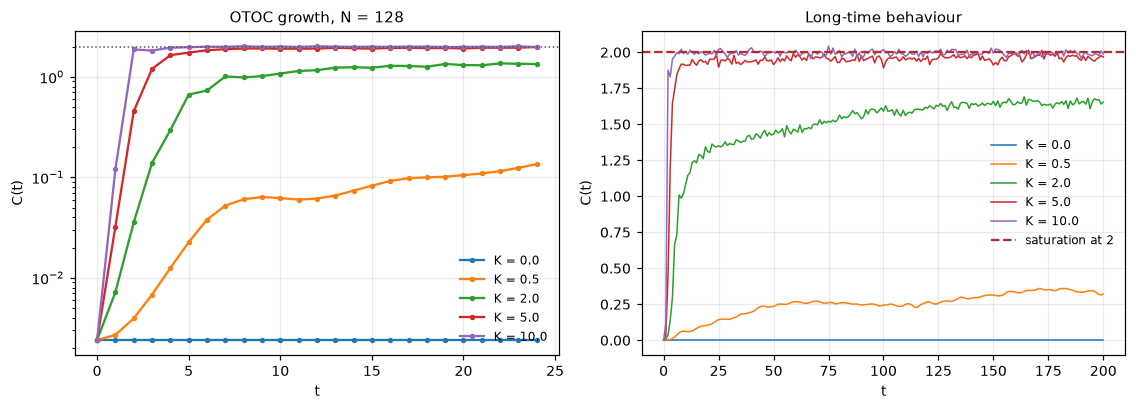

K =   0.0   C(0) = 0.00241   C(4) = 0.00241   max = 0.0024   平均(t≥100) = 0.0024
K =   0.5   C(0) = 0.00241   C(4) = 0.01251   max = 0.3604   平均(t≥100) = 0.3046
K =   2.0   C(0) = 0.00241   C(4) = 0.29561   max = 1.6908   平均(t≥100) = 1.6330
K =   5.0   C(0) = 0.00241   C(4) = 1.64513   max = 2.0153   平均(t≥100) = 1.9617
K =  10.0   C(0) = 0.00241   C(4) = 1.95199   max = 2.0426   平均(t≥100) = 1.9946


In [25]:
otoc_kicks = (0.0, 0.5, 2.0, 5.0, 10.0)
otoc_curves = {
    kick: np.asarray(otoc(KickedRotor(N_OTOC, kick), steps=STEPS_OTOC).values)
    for kick in otoc_kicks
}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.4, 3.8))
times = np.arange(STEPS_OTOC + 1)
for kick in otoc_kicks:
    ax0.semilogy(times[:25], otoc_curves[kick][:25], "-o", ms=2.5, label=f"K = {kick}")
ax0.axhline(2.0, color="#555", ls=":", lw=1.0)
ax0.set_xlabel("t")
ax0.set_ylabel("C(t)")
ax0.set_title(f"OTOC growth, N = {N_OTOC}")
ax0.legend(fontsize=8)

for kick in otoc_kicks:
    ax1.plot(times, otoc_curves[kick], "-", lw=1.0, label=f"K = {kick}")
ax1.axhline(2.0, color="#b03030", ls="--", label="saturation at 2")
ax1.set_xlabel("t")
ax1.set_ylabel("C(t)")
ax1.set_title("Long-time behaviour")
ax1.legend(fontsize=8)
fig.tight_layout()
plt.show()

for kick in otoc_kicks:
    curve = otoc_curves[kick]
    print(
        f"K = {kick:5.1f}   C(0) = {curve[0]:.5f}   C(4) = {curve[4]:.5f}   "
        f"max = {curve.max():.4f}   平均(t≥100) = {curve[100:].mean():.4f}"
    )

free = otoc_curves[0.0]
record(
    "11.1",
    "自由ローター K=0 の OTOC の時間変化（丸めのみ）",
    0.0,
    float(np.max(np.abs(free - free[0]))),
    1e-14,
    "absolute",
)
record("11.1", "OTOC 飽和値 (K=10, t≥100 平均)", 2.0, float(otoc_curves[10.0][100:].mean()), 0.01)

$C(4)$ は $K$ を 0.5 から 10 に上げる間に $1.3\times10^{-2}$ から $2.0$ まで、
2 桁以上動く。一方で長時間の値は $K \ge 5$ でどれも $2$ の近傍に落ち着く。

**この飽和は物理であって数値誤差ではない**。$T_q$ と $T_p$ は非有界な $q, p$ ではなく
**有界なユニタリ**なので、$\|[A,B]\| \le 2\|A\|\,\|B\|$ から $C \le 4$ が厳密に成り立つ。
実測では $2$ 前後で止まる（$K=10$, $N=128$ で $t\ge100$ の平均 1.9946、最大 2.0426）。

**成長率は $2\lambda$ ではない。ここではそれを隠さずに報告する。** 3 つの理由がある。

1. $C(t)$ は安定性乗数の**2 次モーメント**を測るので、成長率は 2 次の一般化 Lyapunov
   指数であり、有限時間指数が揺らぐ限り $\ge 2\lambda$ になる。
2. Ehrenfest 時間 $t_E \sim \ln(1/\hbar_{\rm eff})/\lambda$ は $K=10$, $N=512$ で
   わずか $2.7$ ステップしかない。フィット窓が指数成長の続く区間より長くなり、
   飽和が率を引き下げる。
3. 半古典窓を広げる手段がない。$\hbar_{\rm eff}$ はトーラス量子化で $N$ に縛られており、
   $N$ を上げる代償は $O(N^3)$ である。

`otoc` の docstring に測定値がある（$K = 1, 2, 5, 10$ で率$/2\lambda$ が
8.00, 2.02, 1.09, 0.55 と 1 をまたいで動き、収束しない）。
**使うべきは領域間の比であって絶対的な率ではない。**

### 11.2 Loschmidt echo — KAM 閾値をまたぐ 2 桁以上の分離

摂動を $\delta K = 10^{-2}$ に固定し、$K$ だけを動かす。よく知られた結果は、
**同じ摂動に対する減衰が可積分領域とカオス領域で桁で違う**ことである。

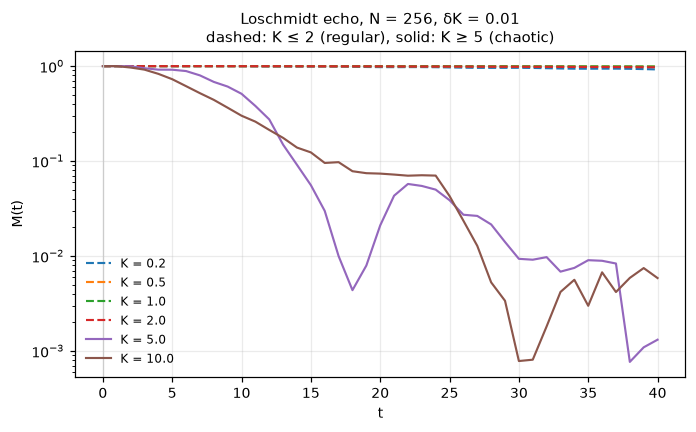

K =   0.2   M(0) - 1 = -4.44e-16   M(20) = 0.976508   M(40) = 9.231e-01
K =   0.5   M(0) - 1 = -4.44e-16   M(20) = 0.997523   M(40) = 9.883e-01
K =   1.0   M(0) - 1 = -4.44e-16   M(20) = 0.998252   M(40) = 9.917e-01
K =   2.0   M(0) - 1 = -4.44e-16   M(20) = 0.993132   M(40) = 9.740e-01
K =   5.0   M(0) - 1 = -4.44e-16   M(20) = 0.020998   M(40) = 1.314e-03
K =  10.0   M(0) - 1 = -4.44e-16   M(20) = 0.073779   M(40) = 5.857e-03

最も減衰した正則側 M(40) = 0.9740
最も減衰しなかったカオス側 M(40) = 5.857e-03
分離 = 166.3 倍


In [26]:
echo_kicks = (0.2, 0.5, 1.0, 2.0, 5.0, 10.0)
DELTA_K, N_ECHO, STEPS_ECHO = 1e-2, 256, 40
echo_state = coherent_state(dimension=N_ECHO, position=0.5, momentum=0.0)
echoes = {
    kick: np.asarray(
        loschmidt_echo(
            KickedRotor(N_ECHO, kick),
            KickedRotor(N_ECHO, kick + DELTA_K),
            echo_state,
            steps=STEPS_ECHO,
            method="fft",
        ).values
    )
    for kick in echo_kicks
}

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for kick in echo_kicks:
    style = "--" if kick <= 2.0 else "-"
    ax.semilogy(np.arange(STEPS_ECHO + 1), echoes[kick], style, lw=1.4, label=f"K = {kick}")
ax.axvline(0.0, color="#ccc", lw=0.8)
ax.set_xlabel("t")
ax.set_ylabel("M(t)")
ax.set_title(
    f"Loschmidt echo, N = {N_ECHO}, δK = {DELTA_K}\ndashed: K ≤ 2 (regular), solid: K ≥ 5 (chaotic)"
)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

for kick in echo_kicks:
    curve = echoes[kick]
    print(
        f"K = {kick:5.1f}   M(0) - 1 = {curve[0] - 1.0:+.2e}   "
        f"M(20) = {curve[20]:.6f}   M(40) = {curve[40]:.3e}"
    )

worst_regular = min(echoes[k][STEPS_ECHO] for k in (0.5, 1.0, 2.0))
best_chaotic = max(echoes[k][STEPS_ECHO] for k in (5.0, 10.0))
separation = worst_regular / best_chaotic
print(f"\n最も減衰した正則側 M(40) = {worst_regular:.4f}")
print(f"最も減衰しなかったカオス側 M(40) = {best_chaotic:.3e}")
print(f"分離 = {separation:.1f} 倍")
# 実測 166 倍。KAM 閾値 K_c = 0.9716 をまたぐと、同じ摂動で 2 桁以上変わる。
assert separation > 100.0, f"領域分離が失われた: {separation:.1f} 倍"

record("11.2", "Loschmidt M(0) = 1（規格化 1 回分の丸め）", 1.0, float(echoes[5.0][0]), 1e-14)

$M(0)$ は構成上 $1$ である。基底状態のように振幅が厳密に表現できる場合は
**ビット厳密に** $1.0$ になり、それ以外でも規格化 1 回分の丸めの精度で $1$ になる
（$N=128$ でランダム状態 200 個に対する最悪誤差 $2.2\times10^{-16}$）。
上の実測は $-4.4\times10^{-16}$ で、コヒーレント状態の規格化の丸めそのものである。

**値は $[0,1]$ にクリップしていない。** $M(t)$ は $1$ を $1.8\times10^{-15}$ まで
超えることがある。クリップした診断は、報告すべき数値ドリフトをちょうど隠してしまう。

**正直な注意が 2 つある。**

- **$K$ に対して単調ではない。** $K=0.2$ は $K=0.5$ より**大きく**減衰する。
  ここで使ったコヒーレント状態は $K=0.5$ では大きな島の中に座るが、$K=0.2$ では
  ずっと平坦で広がった地形に置かれるためである。
- **カオス側でも単調ではない。** $K=10$ は $K=5$ より**減衰しない**。echo が実際に
  応答するのは $\delta K/\hbar_{\rm eff}$ であり、golden-rule 領域はこれに対して
  単調ではない。

診断として使えるのは**2 つの領域の間の分離**であって、領域内部の順序ではない。

---
## 12. まとめ

このノートブックで比較した理論値と実測値を一覧にする。**この表は印刷するだけでなく
検証する**: 各値には許容が付いており、外れたセルは `AssertionError` を送出する。
ノートブックを実行する CI ジョブは例外でしか失敗しないので、表を印刷するだけでは
すべての数値が狂っていても緑のままになってしまう。

`Σ²(L=10)` だけは「期待されるずれ」として上限と下限の両方を課している。RMT が
Thouless エネルギーに対応するスケールを超えると成り立たないことは第 8 節で示した
物理そのものなので、ずれが消えた場合もそれは再現の失敗である。

In [27]:
print(f"{'節':>5}  {'量':<44} {'理論値':>12} {'実測値':>12} {'差':>10} {'許容':>10}")
print("-" * 104)
for section_id, quantity, theory, measured, tolerance, kind in SUMMARY:
    if kind == "absolute":
        deviation = f"{measured - theory:+.1e}"
        allowed = f"{tolerance:.0e}"
    else:
        deviation = f"{(measured - theory) / abs(theory):+.2%}"
        allowed = f"{tolerance:.1%}" + ("*" if kind == "band" else "")
    print(
        f"{section_id:>5}  {quantity:<44} {theory:12.6f} {measured:12.6f} "
        f"{deviation:>10} {allowed:>10}"
    )
print("\n* = 期待されるずれ（下限も課している。詳細は各節の本文）")

failures = summary_failures()
if failures:
    raise AssertionError(
        f"{len(failures)} 個の再現値が許容を外れました:\n  " + "\n  ".join(failures)
    )
print(f"\n{len(SUMMARY)} 個の再現値がすべて許容内です。")

    節  量                                                     理論値          実測値          差         許容
--------------------------------------------------------------------------------------------------------
  2.1  cat 写像 λ₊ = ln((3+√5)/2)                         0.962424     0.962424     -0.00%       0.0%
  2.1  cat 写像 λ₊ + λ₋（面積保存）                             0.000000     0.000000   +0.0e+00      1e-12
  2.2  標準写像 λ(K=50) ≈ ln(K/2)                           3.218876     3.218120     -0.02%       0.5%
    3  D/D_QL at K=10 (Rechester–White)                 0.620413     0.637099     +2.69%      10.0%
  3.1  MSD 指数 α (K=10, 通常拡散)                            1.000000     1.038634     +3.86%       6.0%
  4.1  テント写像 λ = ln 2                                   0.693147     0.693147     -0.00%       0.0%
  4.1  テント写像の不変密度の平均 (= 1/n_cells)                      0.001953     0.001953     +0.00%       0.0%
  4.2  cat 写像の Ulam 不変密度の平均 (= 1/n_cells)               0.000434     0.000434     +0.00%       

### 再現できたもの

1. **$K_c = 0.9716$ での KAM トーラス崩壊** — 運動量方向の輸送が $K \le 1.00$ で完全に
   閉じ込められ、$K = 1.05$ で開放される（閾値が数 % 上にずれるのは critical slowing down）。
2. **cat 写像の Lyapunov 指数** — 厳密値 $\ln\frac{3+\sqrt5}{2}$ と $10^{-6}$ 台で一致、
   面積保存 $\lambda_+ + \lambda_- = 0$ も機械精度。
3. **標準写像の $\lambda \simeq \ln(K/2)$** — $K \ge 20$ で $10^{-2}$ 台の一致。
4. **Rechester–White の Bessel 振動** — $D(K)/D_{\rm QL}$ の振動の位相と振幅が一致し、
   加速器モード近傍のずれも既知の異常拡散として説明できる。
5. **逆正弦則** — Ulam 近似がロジスティック写像の絶対連続不変測度を再現。
6. **テント写像の $\lambda = \ln 2$ と一様不変測度** — `ClassicalMap` プロトコルに
   適合するクラスを自分で書き、ライブラリの `build_ulam` と Lyapunov 推定に載せた。
7. **cat 写像の一様不変測度** — Ulam の Perron ベクトルが機械精度で $1/n_{\rm cells}$。
8. **Percival の regular/irregular 分類** — Husimi 分布が古典の島とカオスの海を分離。
9. **BGS 予想と対称性クラス** — Poisson / COE / CUE の 3 クラスすべてを、
   Bloch 位相で対称性を制御して間隔分布と $\langle r\rangle$ の両方で確認。
10. **ramp–plateau と COE/CUE の因子 2** — 形状因子が RMT 曲線に載る。
11. **スペクトル剛性** — number variance の対数則、$\beta$ に対する $2/\beta$ の比。
    $L \lesssim 3$ で数 % 一致、$L = 14$ では +15% の系統的超過（RMT の適用限界）。
12. **量子 cat 写像の算術的縮退** — 「古典カオス ⇒ RMT」の有名な反例。
13. **動的局在と $\ell \propto D$** — `CylinderKickedRotor` で古典拡散からの離脱と
    指数局在を再現。飽和分布の減衰長を2通りで測って 1% 一致（どちらも $\ell_{\rm dist}$。
    $\ell \approx D/2$ が指すのは固有関数の $\ell_{\rm eig}$ で、その約2倍が
    $\ell_{\rm dist}$）。
14. **Loschmidt echo と OTOC** — OTOC の $C(0) = 4\sin^2(\pi/N)$ を閉じた式と
    $10^{-18}$ で一致させ、自由ローターでの定数性を丸めの精度で確認。有界ユニタリゆえの
    飽和 $C \to 2$ と、KAM 閾値をまたぐ echo の 166 倍の分離を再現。どちらも
    量子 Lyapunov 指数のフィットには使えない（成長率は 2 次の一般化指数であり、
    Ehrenfest 窓がこの次元では数ステップしかない）。

### 残る注意点

再現の過程で見つかった API の欠落は塞がれている。`CylinderKickedRotor`（第 10 節）、
`desymmetrize`、`rmt_reference("spacing_distribution", ...)`、`mean_gap_ratio_reference`、
`poincare_section`、`LogisticMap`、輸送統計のバッチ対応と FFT 経路がそれである。
残るのは物理と数値の側の注意点だけである。

- **未分解のスペクトルを RMT と比べてはいけない**。第 6 節で見たとおり、パリティが
  残った状態の $\langle r\rangle$ は 0.41 で、COE 参照 0.5307 とも Poisson 0.3863 とも
  合わない。Bloch 位相で対称性を破るか、`desymmetrize` で射影すること。
  `prepare_eigenphases(symmetry_sector=...)` はラベルを記録するだけで分解はしない。
- **RMT は長距離では成り立たない**。number variance は $L \lesssim 3$ で数 % 一致するが
  $L = 14$ では +16% 上振れする（第 8 節）。unfolding の方法によるものではなく、
  Thouless エネルギーに対応するスケールを超えると短周期軌道の非普遍的な寄与が残る。
- **キックドローター自体が有限 $N$ で RMT からずれる**。第 6 節の CUE 条件で
  $\langle r\rangle$ は参照値を 1–2% 下回る。Haar 分布ユニタリを同じ関数群に通すと
  参照値に乗るので（`docs/tutorials/spectral_statistics.py` の対照実験）、これは
  パイプラインではなくモデルの性質である。
- **形状因子は自己平均しない**。第 7 節では 80 実現の平均でも $\tau \approx 1$ 付近に
  10–30% の揺らぎが残る。`bootstrap` は再標本化誤差の推定でアンサンブル平均の代わりに
  ならない。
- **巻き戻された座標から真の変位は復元できない**。第 3 節では運動量をキックから厳密に
  積分した。`mean_square_displacement(unwrap=True)` は 1 ステップ変位が周期の半分に
  達する入力を拒否する（標準写像では $K = \pi$ が境界）。
- **脱対称化は必要だが十分ではない**。baker 写像を $N=2^k$ で取ると、パリティで
  分解しても $\langle r\rangle$ は 0.38–0.46 に留まり COE に届かない（第 9 節）。
  RMT と比べるなら非 2 冪の $N$ を選ぶこと。
- **拡散指数の誤差はアンサンブルからしか得られない**。1 本の MSD 曲線では隣接ラグが
  強く相関するので、`local_diffusion_exponent` は `uncertainty=None` を返して警告する
  （第 3.1 節）。
- **Ulam 構築はセル数の 2 乗で効く**。実用上限は $256 \times 256$ 程度で、
  `samples_per_cell` を増やすのはほぼ無料である。